# OpenKind — Phase 4D Evidence-Aware Applicability Residual

**Purpose:** test whether explicit evidence and uncertainty diagnostics are sufficient to repair the remaining cross-partition semantic-none failure while preserving the selected B2 ranking path. This is one pre-registered seed-17 feature-sufficiency experiment—not a sweep.

**Workbench version:** `4d.0.0`  
**Immutable feature/corpus run:** `20260921T013558Z`  
**Immediate parent:** Phase 4C `b2_app_headonly_guard18_s17`, selected epoch 0  
**Underlying checkpoint:** exact Phase 4B.2 `b2_applicability_stratified_s17` selection  
**Run label:** `b2_evidence_residual_s17`  
**Final split:** unavailable by construction

## Why this experiment follows the earlier phases

| Phase | Decisive non-final result | Decision recorded here |
|---|---|---|
| 4A.2 | B2 factorization was the best new architecture (`source-macro NLL 0.54949`, macro-F1 `0.58056`) but QASPER semantic-none behavior remained weak. | Keep the B2 query/ranking representation. |
| 4B.2 | Source/class-balanced applicability training improved the applicability tradeoff; the selected parent reached calibration-gate source-macro NLL `0.57085`, but its transferred automation-policy cost was `0.11675` (> `0.10`). | Preserve this checkpoint as the ranking and representation parent. |
| 4B.3 | Pairwise applicability training did not transport: calibration-gate false-none rates were about `0.211` for both sources, policy-development QASPER recall was `0.2821`, and proper scores regressed. | Do not increase pairwise weight or run another pairwise sweep. |
| 4C | The unchanged parent (epoch 0) beat every head-only child on development NLL (`0.56457`; child epochs `0.58351`, `0.59079`, `0.58022`). Policy-development QASPER recall was `10/39 = 0.2564`, while calibration-gate recall was `28/90 = 0.3111`; transferred policy cost remained `0.11675`. | Existing pooled features are not sufficient for head-only recovery. Add explicit diagnostics rather than retuning the same head. |

Phase 4D freezes the full parent, including the original applicability MLP, and adds a zero-initialized residual branch over 19 bounded features: parent applicability, rank entropy/margin/statistics, question–candidate compatibility, question–state compatibility, and cross-attention concentration. Every feature is available at inference; targets, applicability reasons, and annotated evidence masks are never model inputs. The child may replace epoch 0 only after clearing the stricter development recall guard and proper-score non-regression gate. All eight registered epochs run; there is no opportunistic early stopping.

The terminal non-final pass requires development eligibility, policy-development applicability eligibility, calibration-gate applicability eligibility, transferred policy cost at or below `0.10`, and per-source plus source-macro NLL/Brier non-regression. If the arm fails, stop frozen-feature residual tuning and move to reviewed supervision or representation learning. If it passes, preserve it unchanged and register seeds 42 and 123 in a separate replication contract.


## Recommended run

Run once, top to bottom, in a BF16-capable Colab GPU runtime with the configuration unchanged.

- Leave `RUN_VARIANT=True`, `RESUME=True`, and `RECOMPUTE_NONFINAL=False`.
- Do not rename the run or change the parent, seed, feature set, learning rate, epoch count, or gates.
- If Colab disconnects, rerun all cells. Hash-checked checkpoints resume after the last completed epoch; a completed report is reused.
- Let all eight registered epochs finish. Phase 4D deliberately does not early-stop.
- Epoch 0 is the exact parent prediction function represented in the augmented model. An ineligible child can never displace it.
- Do not open final and do not launch replication seeds from this notebook.

The last cell prints a single terminal outcome and the exact failed/pass components.


## 1. Runtime and dependency contract

Select a Colab GPU runtime. The install is constrained so pip cannot silently replace Colab's Torch build.


In [1]:
import sys, subprocess, importlib.metadata as im, json, os, platform
from pathlib import Path

def installed(name):
    try:
        return im.version(name)
    except im.PackageNotFoundError:
        return None

torch_version = installed("torch")
if torch_version is None:
    raise RuntimeError("Select a Colab GPU runtime with PyTorch installed.")

constraint = Path("/content/openkind_phase4d_torch_constraint.txt")
constraint.write_text(f"torch=={torch_version}\n")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "-c", str(constraint),
    "transformers==5.17.0",
    "accelerate==1.14.0",
    "safetensors==0.8.0",
    "numpy>=2,<3",
    "scipy>=1.16,<2",
    "pandas>=2,<3",
    "scikit-learn>=1.6,<2",
    "pyarrow>=18,<30",
    "matplotlib>=3.9,<4",
])
if installed("torch") != torch_version:
    raise RuntimeError("Torch changed unexpectedly during dependency installation.")

ENVIRONMENT = {
    "python": sys.version,
    "platform": platform.platform(),
    "packages": {name: installed(name) for name in (
        "torch", "transformers", "accelerate", "safetensors", "numpy",
        "scipy", "pandas", "scikit-learn", "pyarrow", "matplotlib",
    )},
}
print(json.dumps(ENVIRONMENT, indent=2))
if not torch_version.startswith("2.11."):
    print("WARNING: the original cache was produced in the Torch 2.11 family.")


{
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "packages": {
    "torch": "2.11.0+cu128",
    "transformers": "5.17.0",
    "accelerate": "1.14.0",
    "safetensors": "0.8.0",
    "numpy": "2.1.3",
    "scipy": "1.16.3",
    "pandas": "2.2.3",
    "scikit-learn": "1.6.1",
    "pyarrow": "23.0.1",
    "matplotlib": "3.10.0"
  }
}


## 2. Mount Google Drive

The Phase 4A.1 feature/corpus run, Phase 4A.2 comparison tree, and completed Phase 4B.2 cap-12 run are read-only inputs. New checkpoints and reports go to a separately labeled directory under the Phase 4B.2 results tree.


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 3. Configure the single Phase 4D feature-sufficiency arm


In [3]:
import gc
import hashlib
import json
import math
import random
import re
import shutil
import zipfile

from collections import defaultdict
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path

WORKBENCH_VERSION = "4d.0.0"
BASE_RUN_ID = "20260921T013558Z"
SEED = 17

VARIANT = "b2_factorized"
RUN_LABEL = "b2_evidence_residual_s17"
RUN_VARIANT = True
RESUME = True
RECOMPUTE_NONFINAL = False

DIAGNOSTIC_FEATURE_NAMES = (
    "parent_applicability_probability",
    "parent_applicability_logit_tanh",
    "candidate_rank_entropy",
    "candidate_rank_max_tanh",
    "candidate_rank_mean_tanh",
    "candidate_rank_std_tanh",
    "candidate_rank_top_margin_tanh",
    "candidate_count_scaled",
    "question_candidate_cosine_mean",
    "question_candidate_cosine_max",
    "question_candidate_cosine_std",
    "question_candidate_cosine_margin",
    "question_state_cosine_mean",
    "question_state_cosine_max",
    "question_state_cosine_std",
    "question_state_similarity_entropy",
    "cross_attention_entropy",
    "cross_attention_max",
    "cross_attention_top4_mass",
)

if VARIANT != "b2_factorized":
    raise ValueError("Phase 4D is locked to the B2 factorized architecture.")
if not re.fullmatch(r"[a-z0-9][a-z0-9._-]{0,79}", RUN_LABEL):
    raise ValueError("RUN_LABEL must be a short path-safe identifier.")
if len(DIAGNOSTIC_FEATURE_NAMES) != 19:
    raise AssertionError("The registered diagnostic feature vector must have length 19.")

CFG = {
    "schema": "openkind-phase4d-evidence-residual-config/v1",
    "workbench_version": WORKBENCH_VERSION,
    "base_run_id": BASE_RUN_ID,
    "variant": VARIANT,
    "run_label": RUN_LABEL,
    "architecture": "B2",
    "state_refiner_layers": 0,
    "seed": SEED,

    "query_dim": 768,
    "query_heads": 12,
    "query_layers": 2,
    "question_latents": 8,
    "max_question_tokens": 96,
    "max_candidate_tokens": 64,

    "diagnostic_feature_names": list(DIAGNOSTIC_FEATURE_NAMES),
    "diagnostic_feature_dim": len(DIAGNOSTIC_FEATURE_NAMES),
    "residual_hidden_dim": 64,
    "residual_dropout": 0.10,
    "residual_initialization": "zero_final_linear_exact_parent_replay",

    "epochs": 8,
    "gradient_accumulation_states": 4,
    "learning_rate": 5e-4,
    "weight_decay": 0.01,
    "source_balance_strategy": "undersample_to_smallest_source_each_epoch",

    "training_objective": (
        "frozen_parent_plus_zero_initialized_evidence_diagnostic_"
        "applicability_residual_source_class_balanced_bce"
    ),
    "trainable_scope": "applicability_residual_only",
    "rank_loss_population": "frozen_parent_no_rank_optimization",
    "applicability_balance_strategy": "equal_source_class_question_mass_per_epoch",
    "applicability_loss_weight": 1.0,
    "scalar_semantic_none_weighting": False,
    "pairwise_applicability_loss": False,

    "minimum_development_none_recall": {
        "contractnli": 0.35,
        "qasper": 0.30,
    },
    "development_selection_none_recall_guard": {
        "contractnli": 0.40,
        "qasper": 0.35,
    },
    "selection_false_none_rate_cap": {
        "contractnli": 0.18,
        "qasper": 0.18,
    },
    "formal_gate_false_none_rate_cap": {
        "contractnli": 0.20,
        "qasper": 0.20,
    },
    "proper_score_tolerance": 0.01,
    "policy_wrong_cost": 5.0,
    "policy_review_cost": 0.10,
    "maximum_policy_cost": 0.10,
}

COLAB_ROOT = Path("/content/drive/MyDrive/Colab Notebooks")
BASE_RUN = COLAB_ROOT / "OpenKind_Phase4A_StateQuery_results" / BASE_RUN_ID
PHASE4A2_COMPARISON_ROOT = (
    COLAB_ROOT / "OpenKind_Phase4A2_StateQuery_Model_Comparison_results" / BASE_RUN_ID
)
PHASE4B2_COMPARISON_ROOT = (
    COLAB_ROOT / "OpenKind_Phase4B2_StateQuery_Model_Comparison_results" / BASE_RUN_ID
)
PHASE4B3_COMPARISON_ROOT = (
    COLAB_ROOT / "OpenKind_Phase4B3_Applicability_Ranking_Sweep_results" / BASE_RUN_ID
)
PHASE4C_COMPARISON_ROOT = (
    COLAB_ROOT / "OpenKind_Phase4C_Decoupled_Applicability_results" / BASE_RUN_ID
)
COMPARISON_ROOT = (
    COLAB_ROOT / "OpenKind_Phase4D_EvidenceAware_Applicability_results" / BASE_RUN_ID
)

PARENT_RUN_LABEL = "b2_app_headonly_guard18_s17"
PARENT_RUN = PHASE4C_COMPARISON_ROOT / PARENT_RUN_LABEL

VARIANT_DIR = COMPARISON_ROOT / RUN_LABEL
LOCAL_ROOT = Path("/content/openkind_phase4d") / BASE_RUN_ID / RUN_LABEL
LOCAL_CACHE = Path("/content/openkind_phase4d_cache") / BASE_RUN_ID

for path in (COMPARISON_ROOT, VARIANT_DIR, LOCAL_ROOT, LOCAL_CACHE):
    path.mkdir(parents=True, exist_ok=True)

print(json.dumps(CFG, indent=2, allow_nan=False))
print("Immutable feature/corpus input:", BASE_RUN)
print("Locked Phase 4C parent:", PARENT_RUN)
print("Phase 4D output:", VARIANT_DIR)
print("Resume enabled:", RESUME)


{
  "schema": "openkind-phase4d-evidence-residual-config/v1",
  "workbench_version": "4d.0.0",
  "base_run_id": "20260921T013558Z",
  "variant": "b2_factorized",
  "run_label": "b2_evidence_residual_s17",
  "architecture": "B2",
  "state_refiner_layers": 0,
  "seed": 17,
  "query_dim": 768,
  "query_heads": 12,
  "query_layers": 2,
  "question_latents": 8,
  "max_question_tokens": 96,
  "max_candidate_tokens": 64,
  "diagnostic_feature_names": [
    "parent_applicability_probability",
    "parent_applicability_logit_tanh",
    "candidate_rank_entropy",
    "candidate_rank_max_tanh",
    "candidate_rank_mean_tanh",
    "candidate_rank_std_tanh",
    "candidate_rank_top_margin_tanh",
    "candidate_count_scaled",
    "question_candidate_cosine_mean",
    "question_candidate_cosine_max",
    "question_candidate_cosine_std",
    "question_candidate_cosine_margin",
    "question_state_cosine_mean",
    "question_state_cosine_max",
    "question_state_cosine_std",
    "question_state_similar

## 4. Verify immutable inputs and the locked Phase 4C result


In [4]:
import numpy as np
import pandas as pd

def json_safe(value):
    """Recursively replace non-finite numeric values with JSON null."""
    if isinstance(value, np.ndarray):
        return [json_safe(item) for item in value.tolist()]
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


def canonical_bytes(obj):
    return json.dumps(
        json_safe(obj),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=False,
        allow_nan=False,
    ).encode()


def sha256_obj(obj):
    return hashlib.sha256(canonical_bytes(obj)).hexdigest()


def sha256_file(path, chunk=4 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as handle:
        while block := handle.read(chunk):
            h.update(block)
    return h.hexdigest()


def _reject_json_constant(token):
    raise ValueError(f"Non-standard JSON numeric constant: {token}")


def read_json(path):
    return json.loads(
        Path(path).read_text(),
        parse_constant=_reject_json_constant,
    )


def atomic_json(obj, destination):
    destination = Path(destination)
    tmp = destination.with_name(destination.name + ".partial")
    tmp.write_text(json.dumps(
        json_safe(obj),
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    ))
    os.replace(tmp, destination)


_json_probe = json.dumps(
    json_safe({"nan": np.nan, "pos": np.inf, "neg": -np.inf}),
    allow_nan=False,
)
assert json.loads(_json_probe) == {"nan": None, "pos": None, "neg": None}
try:
    json.loads('{"bad": NaN}', parse_constant=_reject_json_constant)
except ValueError:
    pass
else:
    raise AssertionError("Strict JSON reader accepted NaN.")
print("Strict JSON serialization contract passed: non-finite values become null.")


required_base = [
    "DECLARED_CONTRACT.json", "TRAINING_REPORT.json", "NONFINAL_EVALUATION.json",
    "MODEL_SELECTION_LOCK.json", "query_model_best.safetensors",
    "reference_nonfinal_predictions.parquet",
]
missing = [name for name in required_base if not (BASE_RUN / name).is_file()]
if missing:
    raise FileNotFoundError(f"Incomplete base run {BASE_RUN_ID}: {missing}")
if (BASE_RUN / "FINAL_EVALUATION.json").exists():
    raise RuntimeError("The immutable base run's final split has been opened.")

BASE_DECLARED = read_json(BASE_RUN / "DECLARED_CONTRACT.json")
claimed_declared_hash = BASE_DECLARED.get("sha256")
declared_payload = dict(BASE_DECLARED)
declared_payload.pop("sha256", None)
if sha256_obj(declared_payload) != claimed_declared_hash:
    raise RuntimeError("The base declared contract changed.")
MODEL_CONTRACT = BASE_DECLARED["model"]

CORPUS_ROOT = BASE_RUN / "openkind-mq-v1"
CORPUS_MANIFEST = read_json(CORPUS_ROOT / "manifest.json")
CORPUS_LOCK = read_json(CORPUS_ROOT / "corpus_lock.json")
if CORPUS_MANIFEST["run_id"] != BASE_RUN_ID:
    raise RuntimeError("Corpus run ID mismatch.")
if sha256_obj(CORPUS_MANIFEST) != CORPUS_LOCK["manifest_sha256"]:
    raise RuntimeError("Corpus manifest no longer matches its lock.")
if CORPUS_MANIFEST.get("final_labels_or_predictions_opened") is not False:
    raise RuntimeError("Corpus manifest does not attest that final stayed closed.")

frames = {}
for name, expected_hash in CORPUS_LOCK["tables"].items():
    path = CORPUS_ROOT / f"{name}.parquet"
    got_hash = sha256_file(path)
    if got_hash != expected_hash:
        raise RuntimeError(f"Changed corpus table {name}: {got_hash}")
    frames[name] = pd.read_parquet(path)
    if len(frames[name]) != CORPUS_MANIFEST["counts"][name]:
        raise RuntimeError(f"Row count changed for {name}.")

FEATURE_ROOT = BASE_RUN / "state_features"
FEATURE_MANIFEST_PATH = FEATURE_ROOT / "manifest.json"
FEATURE_MANIFEST = read_json(FEATURE_MANIFEST_PATH)
if FEATURE_MANIFEST["run_id"] != BASE_RUN_ID:
    raise RuntimeError("Feature-cache run ID mismatch.")
if FEATURE_MANIFEST["corpus_manifest_sha256"] != CORPUS_LOCK["manifest_sha256"]:
    raise RuntimeError("Feature cache belongs to another corpus.")
if FEATURE_MANIFEST.get("reference_predictions_exclude_final") is not True:
    raise RuntimeError("Stage A did not attest that reference predictions exclude final.")
manifest_state_ids = [record["state_id"] for record in FEATURE_MANIFEST["state_files"]]
if len(manifest_state_ids) != len(set(manifest_state_ids)):
    raise RuntimeError("Duplicate state IDs in feature manifest.")
if set(manifest_state_ids) != set(frames["states"]["state_id"]):
    raise RuntimeError("Feature manifest does not cover the locked state table exactly.")
final_state_ids = set(
    frames["states"].loc[frames["states"]["split"] == "final", "state_id"]
)
final_question_ids = set(
    frames["questions"].loc[
        frames["questions"]["state_id"].isin(final_state_ids), "question_id"
    ]
)
control_question_ids = {
    record["question_id"]
    for record in FEATURE_MANIFEST.get("candidate_conditioned_control_files", [])
}
if control_question_ids & final_question_ids:
    raise RuntimeError("Matched-control cache unexpectedly includes final questions.")

BASE_TRAINING = read_json(BASE_RUN / "TRAINING_REPORT.json")
BASE_NONFINAL = read_json(BASE_RUN / "NONFINAL_EVALUATION.json")
BASE_LOCK = read_json(BASE_RUN / "MODEL_SELECTION_LOCK.json")
if any(report.get("final_opened") is not False for report in (BASE_TRAINING, BASE_NONFINAL, BASE_LOCK)):
    raise RuntimeError("A base report does not attest that final remained closed.")
if sha256_file(BASE_RUN / "query_model_best.safetensors") != BASE_LOCK["checkpoint_sha256"]:
    raise RuntimeError("Base selected checkpoint changed.")
if sha256_file(BASE_RUN / "NONFINAL_EVALUATION.json") != BASE_LOCK["nonfinal_report_sha256"]:
    raise RuntimeError("Base non-final report changed.")

parent_required = [
    "EXPERIMENT_CONTRACT.json",
    "TRAINING_REPORT.json",
    "NONFINAL_EVALUATION.json",
    "NONFINAL_RESULT_LOCK.json",
]
missing_parent = [name for name in parent_required if not (PARENT_RUN / name).is_file()]
if missing_parent:
    raise FileNotFoundError(
        f"Incomplete locked Phase 4C parent {PARENT_RUN_LABEL}: {missing_parent}"
    )

PARENT_CONTRACT = read_json(PARENT_RUN / "EXPERIMENT_CONTRACT.json")
PARENT_TRAINING = read_json(PARENT_RUN / "TRAINING_REPORT.json")
PARENT_NONFINAL = read_json(PARENT_RUN / "NONFINAL_EVALUATION.json")
PARENT_LOCK = read_json(PARENT_RUN / "NONFINAL_RESULT_LOCK.json")

EXPECTED_PARENT_EXPERIMENT_SHA256 = (
    "396748e3f495403dd5cdccf1a6708ddc3de815e2f54fcf75e0b92525a27037ef"
)
EXPECTED_PARENT_CHECKPOINT_SHA256 = (
    "87c3b3a4069b64e4a150ad6e0812ce2d953346eb17999865770df508269ed871"
)
parent_experiment_sha = PARENT_CONTRACT["experiment_sha256"]
if parent_experiment_sha != EXPECTED_PARENT_EXPERIMENT_SHA256:
    raise RuntimeError("The Phase 4C parent experiment identity changed.")

for name, report in {
    "training": PARENT_TRAINING,
    "non-final": PARENT_NONFINAL,
    "result lock": PARENT_LOCK,
}.items():
    if report.get("experiment_sha256") != parent_experiment_sha:
        raise RuntimeError(f"Phase 4C {name} report belongs to another experiment.")
    if report.get("final_opened") is not False:
        raise RuntimeError(f"Phase 4C {name} report does not keep final closed.")

if PARENT_TRAINING.get("run_label") != PARENT_RUN_LABEL:
    raise RuntimeError("Phase 4C training report has the wrong run label.")
if PARENT_NONFINAL.get("run_label") != PARENT_RUN_LABEL:
    raise RuntimeError("Phase 4C non-final report has the wrong run label.")
if PARENT_TRAINING.get("architecture") != "B2":
    raise RuntimeError("Phase 4C parent is not the B2 architecture.")
if PARENT_TRAINING.get("training_objective") != (
    "locked_parent_initialization_plus_frozen_b2_plus_"
    "applicability_head_only_source_class_balanced_bce"
):
    raise RuntimeError("Phase 4C parent does not have the registered head-only objective.")
if int(PARENT_TRAINING.get("selected_epoch", -1)) != 0:
    raise RuntimeError("Phase 4C no longer selects the unchanged epoch-0 parent.")
if PARENT_TRAINING.get("selected_checkpoint_sha256") != EXPECTED_PARENT_CHECKPOINT_SHA256:
    raise RuntimeError("Phase 4C selected checkpoint identity changed.")

parent_selected_epoch = int(PARENT_TRAINING["selected_epoch"])
parent_selected_record = next(
    row for row in PARENT_TRAINING["history"]
    if int(row["epoch"]) == parent_selected_epoch
)
parent_selected_path = PARENT_RUN / PARENT_TRAINING["selected_checkpoint"]
if not parent_selected_path.is_file():
    raise FileNotFoundError(f"Missing Phase 4C selected checkpoint: {parent_selected_path}")
if sha256_file(parent_selected_path) != EXPECTED_PARENT_CHECKPOINT_SHA256:
    raise RuntimeError("Phase 4C selected checkpoint changed.")
if sha256_file(PARENT_RUN / "NONFINAL_EVALUATION.json") != PARENT_LOCK["nonfinal_report_sha256"]:
    raise RuntimeError("Phase 4C non-final report changed after locking.")
if PARENT_LOCK["selected_checkpoint_sha256"] != EXPECTED_PARENT_CHECKPOINT_SHA256:
    raise RuntimeError("Phase 4C result lock names a different checkpoint.")

EXPECTED_PARENT_FILE_HASHES = {
    "EXPERIMENT_CONTRACT.json": "201a56cc5845a14488354accd8553eb9509633def9954c309357d8bb505a270c",
    "TRAINING_REPORT.json": "3f5bf3ff04387eb0dde61c706a3ac4f706f6706d7d0220018db5d40cd769cc80",
    "NONFINAL_EVALUATION.json": "f8b49ec9de2482706188f1721171d3ce4574f82649803858581bf9cbf4ab4dff",
    "NONFINAL_RESULT_LOCK.json": "75f0d69946e123fb221282f3fc1e7b5346cc67cc295d5eceda5ef4c282824fcf",
}
for filename, expected_hash in EXPECTED_PARENT_FILE_HASHES.items():
    if sha256_file(PARENT_RUN / filename) != expected_hash:
        raise RuntimeError(f"Locked Phase 4C artifact changed: {filename}")

BASE_ARTIFACT_HASHES = {
    "declared_contract": sha256_file(BASE_RUN / "DECLARED_CONTRACT.json"),
    "corpus_manifest": sha256_file(CORPUS_ROOT / "manifest.json"),
    "corpus_lock": sha256_file(CORPUS_ROOT / "corpus_lock.json"),
    "feature_manifest": sha256_file(FEATURE_MANIFEST_PATH),
    "base_training_report": sha256_file(BASE_RUN / "TRAINING_REPORT.json"),
    "base_nonfinal_report": sha256_file(BASE_RUN / "NONFINAL_EVALUATION.json"),
    "base_model_lock": sha256_file(BASE_RUN / "MODEL_SELECTION_LOCK.json"),
    "base_selected_checkpoint": sha256_file(BASE_RUN / "query_model_best.safetensors"),
    "reference_nonfinal_predictions": sha256_file(
        BASE_RUN / "reference_nonfinal_predictions.parquet"
    ),
}
PARENT_PREDICTION_FILES = {
    "calibration_fit": "calibration_fit_predictions.parquet",
    "calibration_gate": "calibration_gate_predictions.parquet",
    "policy_development": "policy_development_predictions.parquet",
}
EXPECTED_PARENT_PREDICTION_HASHES = {
    "calibration_fit": "e0a9ab42e985bad5cd6019c2def4871828ec5c9699894301e01c1f279cb45b1f",
    "calibration_gate": "1eb3541f3a26e8fae01c1926a878c2d5a641981cc0785abfba2d439ef7358f6c",
    "policy_development": "164d665f5b49584c353f7afa8ae60fb9967b4fde98fc6b4a6ba348387d8da03e",
}
for partition, filename in PARENT_PREDICTION_FILES.items():
    prediction_path = PARENT_RUN / filename
    expected = EXPECTED_PARENT_PREDICTION_HASHES[partition]
    if PARENT_NONFINAL["prediction_files_sha256"][partition] != expected:
        raise RuntimeError(f"Phase 4C report prediction hash changed: {partition}")
    if not prediction_path.is_file() or sha256_file(prediction_path) != expected:
        raise RuntimeError(f"Locked Phase 4C prediction table changed: {partition}")

PARENT_ARTIFACT_HASHES = {
    "experiment_contract": sha256_file(PARENT_RUN / "EXPERIMENT_CONTRACT.json"),
    "training_report": sha256_file(PARENT_RUN / "TRAINING_REPORT.json"),
    "nonfinal_report": sha256_file(PARENT_RUN / "NONFINAL_EVALUATION.json"),
    "nonfinal_result_lock": sha256_file(PARENT_RUN / "NONFINAL_RESULT_LOCK.json"),
    "selected_checkpoint": EXPECTED_PARENT_CHECKPOINT_SHA256,
    **{
        f"{partition}_predictions": sha256_file(PARENT_RUN / filename)
        for partition, filename in PARENT_PREDICTION_FILES.items()
    },
}

PARENT_DEVELOPMENT_BY_SOURCE = parent_selected_record["selection"]["by_source"]
PARENT_DEVELOPMENT_SOURCE_MACRO = parent_selected_record["selection"]["source_macro"]

EXPERIMENT_PAYLOAD = {
    "schema": "openkind-phase4d-evidence-residual-experiment/v1",
    "config": CFG,
    "base_artifacts": BASE_ARTIFACT_HASHES,
    "parent_phase4c": {
        "run_label": PARENT_RUN_LABEL,
        "experiment_sha256": parent_experiment_sha,
        "selected_epoch": parent_selected_epoch,
        "artifacts": PARENT_ARTIFACT_HASHES,
        "recorded_failure": {
            "selected_epoch": 0,
            "child_development_nll": [
                row["selection"]["source_macro"]["nll"]
                for row in PARENT_TRAINING["history"] if int(row["epoch"]) > 0
            ],
            "policy_qasper_none_recall": PARENT_NONFINAL[
                "applicability_thresholds_selected_on_policy_development"
            ]["qasper"]["semantic_none_recall"],
            "calibration_qasper_none_recall": PARENT_NONFINAL[
                "calibration_gate_applicability_operating_points"
            ]["qasper"]["semantic_none_recall"],
            "calibration_policy_cost": PARENT_NONFINAL[
                "policy_applied_to_calibration_gate"
            ]["cost"],
        },
    },
    "model_contract": MODEL_CONTRACT,
    "corpus_lock": CORPUS_LOCK,
    "final_split_available": False,
}
EXPERIMENT_SHA256 = sha256_obj(EXPERIMENT_PAYLOAD)
EXPERIMENT_CONTRACT = {
    **EXPERIMENT_PAYLOAD,
    "experiment_sha256": EXPERIMENT_SHA256,
}
contract_path = VARIANT_DIR / "EXPERIMENT_CONTRACT.json"
if contract_path.exists():
    existing = read_json(contract_path)
    if existing.get("experiment_sha256") != EXPERIMENT_SHA256:
        raise RuntimeError(
            f"RUN_LABEL={RUN_LABEL!r} already has a different contract. "
            "Choose a new RUN_LABEL."
        )
else:
    atomic_json(EXPERIMENT_CONTRACT, contract_path)

display(
    frames["states"]
    .groupby(["source", "split"])
    .size()
    .rename("states")
    .reset_index()
)
print("Verified corpus tables:", {name: len(frame) for name, frame in frames.items()})
print("State feature records:", len(FEATURE_MANIFEST["state_files"]))
print("Control-question records:", len(control_question_ids))
print("Locked Phase 4C decision:", {
    "selected_epoch": parent_selected_epoch,
    "selected_checkpoint_sha256": EXPECTED_PARENT_CHECKPOINT_SHA256,
    "development_source_macro_nll": PARENT_DEVELOPMENT_SOURCE_MACRO["nll"],
    "policy_qasper_none_recall": PARENT_NONFINAL[
        "applicability_thresholds_selected_on_policy_development"
    ]["qasper"]["semantic_none_recall"],
    "calibration_qasper_none_recall": PARENT_NONFINAL[
        "calibration_gate_applicability_operating_points"
    ]["qasper"]["semantic_none_recall"],
    "calibration_policy_cost": PARENT_NONFINAL[
        "policy_applied_to_calibration_gate"
    ]["cost"],
})
print("Phase 4D experiment contract:", EXPERIMENT_SHA256)


Strict JSON serialization contract passed: non-finite values become null.


,source,split,states
0,contractnli,calibration_fit,34
1,contractnli,calibration_gate,71
2,contractnli,development,70
3,contractnli,final,52
4,contractnli,policy_development,39
5,contractnli,train,341
6,qasper,calibration_fit,119
7,qasper,calibration_gate,199
8,qasper,development,242
9,qasper,final,217


Verified corpus tables: {'states': 2192, 'questions': 15368, 'options': 25687, 'evidence': 21894, 'criteria': 18}
State feature records: 2192
Control-question records: 13725
Locked Phase 4C decision: {'selected_epoch': 0, 'selected_checkpoint_sha256': '87c3b3a4069b64e4a150ad6e0812ce2d953346eb17999865770df508269ed871', 'development_source_macro_nll': 0.564568435725773, 'policy_qasper_none_recall': 0.2564102564102564, 'calibration_qasper_none_recall': 0.3111111111111111, 'calibration_policy_cost': 0.11674565560821486}
Phase 4D experiment contract: 70ac547c7a257d978cbc241f049fb2dbbc912b0d5801ca28080820d1e183d4c5


## 5. Verify and extract the exact tokenizer bundle

The 4B model is not loaded in this notebook. Only the selected bundle's tokenizer is used for B1/B2 query and candidate text, and the already-cached frozen input embedding is used for token lookup.


In [5]:
EXPECTED_BUNDLE = (
    COLAB_ROOT / "OpenKind_Phase2IJ_results"
    / "2ij_model_selection_screen_v2"
    / "model_bundle_2ij_model_selection_screen_v2.zip"
)
LOCAL_BUNDLE = LOCAL_CACHE / "reference_bundle"

def safe_extract(zpath, destination):
    destination = destination.resolve()
    with zipfile.ZipFile(zpath) as zf:
        for member in zf.infolist():
            target = (destination / member.filename).resolve()
            if not target.is_relative_to(destination):
                raise RuntimeError(f"Unsafe ZIP member: {member.filename}")
        zf.extractall(destination)

if not EXPECTED_BUNDLE.is_file():
    raise FileNotFoundError(EXPECTED_BUNDLE)
if sha256_file(EXPECTED_BUNDLE) != MODEL_CONTRACT["bundle_sha256"]:
    raise RuntimeError("Selected reference bundle changed.")
LOCAL_BUNDLE.mkdir(parents=True, exist_ok=True)
if not (LOCAL_BUNDLE / "BUNDLE_MANIFEST.json").is_file():
    safe_extract(EXPECTED_BUNDLE, LOCAL_BUNDLE)
bundle_manifest = read_json(LOCAL_BUNDLE / "BUNDLE_MANIFEST.json")
bundle_profile = read_json(LOCAL_BUNDLE / "profile.json")
if bundle_manifest["profile_id"] != MODEL_CONTRACT["profile_id"]:
    raise RuntimeError("Bundle profile mismatch.")
if bundle_manifest["base"]["id"] != MODEL_CONTRACT["model_id"]:
    raise RuntimeError("Bundle model mismatch.")
if bundle_manifest["base"]["revision"] != MODEL_CONTRACT["revision"]:
    raise RuntimeError("Bundle revision mismatch.")
for rel, expected in bundle_manifest["files"].items():
    path = LOCAL_BUNDLE / rel
    if not path.is_file() or sha256_file(path) != expected:
        raise RuntimeError(f"Missing or changed bundle member: {rel}")
print("Verified tokenizer bundle:", bundle_profile["profile_id"])


Verified tokenizer bundle: a047d6802c3f06f085b8


## 6. Frozen B2 parent plus FP32 evidence-aware residual


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

REASON_LABELS = ("applicable", "omitted_option", "out_of_scope", "insufficient_evidence", "unobservable_state")

class CrossBlock(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1, ff_mult=4):
        super().__init__()
        self.n1 = nn.LayerNorm(d_model)
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.n2 = nn.LayerNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.n3 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_mult * d_model, d_model), nn.Dropout(dropout),
        )

    def forward(self, x, memory, x_padding=None, memory_padding=None, return_attention=False):
        y = self.n1(x)
        y, _ = self.self_attn(y, y, y, key_padding_mask=x_padding, need_weights=False)
        x = x + y
        y = self.n2(x)
        y, weights = self.cross_attn(
            y, memory, memory,
            key_padding_mask=memory_padding,
            need_weights=return_attention,
            average_attn_weights=False,
        )
        x = x + y
        x = x + self.ff(self.n3(x))
        return x, weights

class QueryStack(nn.Module):
    def __init__(self, layers, d_model, nhead, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([CrossBlock(d_model, nhead, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, memory, x_padding=None, memory_padding=None):
        attention = None
        for i, layer in enumerate(self.layers):
            x, attention = layer(
                x, memory, x_padding, memory_padding,
                return_attention=(i == len(self.layers) - 1),
            )
        return self.norm(x), attention

class StateRefiner(nn.Module):
    def __init__(self, layers, d_model, nhead):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=0.1, activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=layers) if layers else None

    def forward(self, memory, padding=None):
        return self.encoder(memory, src_key_padding_mask=padding) if self.encoder else memory

class StateQueryBase(nn.Module):
    def __init__(self, frozen_embedding, hidden_size=2560, d_model=768, heads=12,
                 layers=2, state_refiner_layers=0):
        super().__init__()
        self.token_embedding = nn.Embedding.from_pretrained(frozen_embedding, freeze=True)
        self.token_proj = nn.Linear(hidden_size, d_model, bias=False)
        self.state_proj = nn.Linear(hidden_size, d_model, bias=False)
        self.state_refiner = StateRefiner(state_refiner_layers, d_model, heads)
        self.rank_head = nn.Linear(d_model, 1)
        self.applicability = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, 1)
        )
        self.reason_head = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, len(REASON_LABELS))
        )
        self.d_model = d_model
        self.layers = layers
        self.heads = heads

    def embed(self, ids):
        return self.token_proj(self.token_embedding(ids))

    def project_state(self, hidden):
        memory = self.state_proj(hidden.float()).unsqueeze(0)
        return self.state_refiner(memory)

    def assemble(self, candidate_features, question_feature):
        feats = torch.stack(candidate_features, dim=0)
        pooled = torch.cat([question_feature, feats.mean(0), feats.max(0).values], dim=-1)
        candidate_logits = self.rank_head(feats).squeeze(-1)
        applicability_logit = self.applicability(pooled).squeeze(-1)
        reason_logits = self.reason_head(pooled)
        return candidate_logits, applicability_logit, reason_logits

class B0CandidateConditioned(nn.Module):
    """Matched-label control over frozen candidate-conditioned Qwen features."""
    def __init__(self, hidden_size=2560, d_model=768):
        super().__init__()
        self.feature_proj = nn.Sequential(
            nn.LayerNorm(hidden_size), nn.Linear(hidden_size, d_model), nn.GELU()
        )
        self.rank_head = nn.Linear(d_model, 1)
        self.applicability = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, 1)
        )
        self.reason_head = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, len(REASON_LABELS))
        )

    def forward_features(self, conditioned_features):
        feats = self.feature_proj(conditioned_features.float())
        mean = feats.mean(0); maximum = feats.max(0).values
        pooled = torch.cat([mean, mean, maximum], dim=-1)
        return {
            "candidate_logits": self.rank_head(feats).squeeze(-1),
            "applicability_logit": self.applicability(pooled).squeeze(-1),
            "reason_logits": self.reason_head(pooled),
            "evidence_attention": None,
            "question_memory": mean.unsqueeze(0),
        }

class B1StateQuery(StateQueryBase):
    def __init__(self, frozen_embedding, **kwargs):
        super().__init__(frozen_embedding, **kwargs)
        self.question_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        self.candidate_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        self.query = QueryStack(self.layers, self.d_model, self.heads)

    def query_once(self, learned, token_ids, memory):
        tokens = self.embed(token_ids).unsqueeze(0)
        x = torch.cat([learned, tokens], dim=1)
        out, attn = self.query(x, memory)
        return out[0, 0], attn

    def forward_memory(self, memory, question_ids, candidate_ids):
        qfeat, qattn = self.query_once(self.question_token, question_ids, memory)
        cfeats = []
        for ids in candidate_ids:
            joined = torch.cat([question_ids, ids])
            feat, _ = self.query_once(self.candidate_token, joined, memory)
            cfeats.append(feat)
        logits, app, reasons = self.assemble(cfeats, qfeat)
        return {"candidate_logits": logits, "applicability_logit": app,
                "reason_logits": reasons, "evidence_attention": qattn,
                "state_memory": memory, "question_memory": qfeat.unsqueeze(0)}

    def forward(self, state_hidden, question_ids, candidate_ids):
        return self.forward_memory(self.project_state(state_hidden), question_ids, candidate_ids)

def _normalized_entropy(probabilities):
    probabilities = probabilities.float().clamp_min(1e-12)
    probabilities = probabilities / probabilities.sum().clamp_min(1e-12)
    if probabilities.numel() <= 1:
        return torch.zeros((), device=probabilities.device, dtype=torch.float32)
    return -(probabilities * probabilities.log()).sum() / math.log(probabilities.numel())


def _top_margin(values):
    values = values.float().reshape(-1)
    if values.numel() <= 1:
        return torch.zeros((), device=values.device, dtype=torch.float32)
    top = torch.topk(values, k=2).values
    return top[0] - top[1]


class B2StateQuery(StateQueryBase):
    def __init__(self, frozen_embedding, question_latents=8, **kwargs):
        super().__init__(frozen_embedding, **kwargs)
        self.latents = nn.Parameter(torch.randn(1, question_latents, self.d_model) * 0.02)
        self.question_stack = QueryStack(self.layers, self.d_model, self.heads)
        self.candidate_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        self.candidate_stack = QueryStack(max(1, self.layers // 2), self.d_model, self.heads)
        self.applicability_residual = nn.Sequential(
            nn.Linear(CFG["diagnostic_feature_dim"], CFG["residual_hidden_dim"]),
            nn.GELU(),
            nn.Dropout(CFG["residual_dropout"]),
            nn.Linear(CFG["residual_hidden_dim"], 1),
        )
        nn.init.zeros_(self.applicability_residual[-1].weight)
        nn.init.zeros_(self.applicability_residual[-1].bias)

    def diagnostic_features(
        self, candidate_logits, parent_applicability_logit,
        candidate_features, question_memory, state_memory, cross_attention,
    ):
        device_type = candidate_logits.device.type
        with torch.autocast(device_type=device_type, enabled=False):
            rank_logits = candidate_logits.float().reshape(-1)
            rank_probabilities = torch.softmax(rank_logits, dim=0)
            candidate_matrix = torch.stack(candidate_features).float()
            qmem = question_memory[0].float()
            qmean = qmem.mean(dim=0)
            state = state_memory[0].float()

            candidate_similarity = F.cosine_similarity(
                candidate_matrix,
                qmean.unsqueeze(0).expand_as(candidate_matrix),
                dim=-1,
            )
            state_similarity = F.cosine_similarity(
                state,
                qmean.unsqueeze(0).expand_as(state),
                dim=-1,
            )
            state_similarity_distribution = torch.softmax(state_similarity, dim=0)

            if cross_attention is None:
                attention_distribution = torch.full(
                    (state.shape[0],),
                    1.0 / max(1, state.shape[0]),
                    device=state.device,
                    dtype=torch.float32,
                )
            else:
                attention_distribution = (
                    cross_attention[0].float().mean(dim=0)[: qmem.shape[0]].mean(dim=0)
                )
                attention_distribution = attention_distribution.clamp_min(0)
                attention_distribution = attention_distribution / attention_distribution.sum().clamp_min(1e-12)

            top4 = min(4, attention_distribution.numel())
            features = torch.stack([
                torch.sigmoid(parent_applicability_logit.float()),
                torch.tanh(parent_applicability_logit.float() / 4.0),
                _normalized_entropy(rank_probabilities),
                torch.tanh(rank_logits.max() / 4.0),
                torch.tanh(rank_logits.mean() / 4.0),
                torch.tanh(rank_logits.std(unbiased=False) / 4.0),
                torch.tanh(_top_margin(rank_logits) / 4.0),
                torch.tensor(
                    min(rank_logits.numel(), 10) / 10.0,
                    device=rank_logits.device,
                    dtype=torch.float32,
                ),
                candidate_similarity.mean(),
                candidate_similarity.max(),
                candidate_similarity.std(unbiased=False),
                _top_margin(candidate_similarity),
                state_similarity.mean(),
                state_similarity.max(),
                state_similarity.std(unbiased=False),
                _normalized_entropy(state_similarity_distribution),
                _normalized_entropy(attention_distribution),
                attention_distribution.max(),
                torch.topk(attention_distribution, k=top4).values.sum(),
            ])
            if features.shape != (CFG["diagnostic_feature_dim"],):
                raise AssertionError(f"Unexpected diagnostic shape: {features.shape}")
            if not torch.isfinite(features).all():
                raise FloatingPointError("Non-finite evidence-aware diagnostic feature.")
            return features

    def forward_memory(self, memory, question_ids, candidate_ids):
        question_tokens = self.embed(question_ids).unsqueeze(0)
        slots = self.latents.expand(1, -1, -1)
        question_input = torch.cat([slots, question_tokens], dim=1)
        question_out, qattn = self.question_stack(question_input, memory)
        qmem = question_out[:, :self.latents.shape[1], :]
        qfeat = qmem.mean(dim=1)[0]
        cfeats = []
        for ids in candidate_ids:
            x = torch.cat([self.candidate_token, self.embed(ids).unsqueeze(0)], dim=1)
            out, _ = self.candidate_stack(x, qmem)
            cfeats.append(out[0, 0])
        logits, parent_app, reasons = self.assemble(cfeats, qfeat)
        diagnostics = self.diagnostic_features(
            logits, parent_app, cfeats, qmem, memory, qattn
        )
        device_type = logits.device.type
        with torch.autocast(device_type=device_type, enabled=False):
            residual = self.applicability_residual(diagnostics.float()).squeeze(-1)
            app = parent_app.float() + residual.float()
        return {
            "candidate_logits": logits,
            "applicability_logit": app,
            "parent_applicability_logit": parent_app.float(),
            "applicability_residual_logit": residual.float(),
            "diagnostic_features": diagnostics,
            "reason_logits": reasons,
            "evidence_attention": qattn,
            "state_memory": memory,
            "question_memory": qmem,
        }

    def forward(self, state_hidden, question_ids, candidate_ids):
        return self.forward_memory(self.project_state(state_hidden), question_ids, candidate_ids)

def choice_distribution(candidate_logits, applicability_logit, rank_temperature=1.0, app_temperature=1.0):
    """Assemble the typed choice distribution in FP32, even inside BF16 autocast."""
    device_type = candidate_logits.device.type
    with torch.autocast(device_type=device_type, enabled=False):
        logits = candidate_logits.float()
        app_logit = applicability_logit.float()
        rank_t = torch.as_tensor(rank_temperature, device=logits.device, dtype=torch.float32)
        app_t = torch.as_tensor(app_temperature, device=logits.device, dtype=torch.float32)
        if torch.any(rank_t <= 0) or torch.any(app_t <= 0):
            raise ValueError("Temperatures must be positive.")
        conditional = torch.softmax(logits / rank_t, dim=-1)
        applicability = torch.sigmoid(app_logit / app_t)
        probs = torch.cat([applicability * conditional, (1.0 - applicability).reshape(1)])
        if not torch.isfinite(probs).all():
            raise FloatingPointError("Non-finite choice probabilities.")
        total = probs.sum()
        one = torch.ones((), device=probs.device, dtype=probs.dtype)
        if not torch.isclose(total.detach(), one, atol=1e-5, rtol=1e-5):
            raise AssertionError(f"Choice probabilities sum to {float(total.detach().cpu()):.9f}, not 1.")
        return probs / total

# CPU shape/permutation contract: no model weights or corpus labels are used.
torch.manual_seed(SEED)
dummy_embedding = torch.randn(101, 32)
test_model = B1StateQuery(dummy_embedding, hidden_size=32, d_model=24, heads=4, layers=2)
test_model.eval()
state = torch.randn(11, 32)
qids = torch.tensor([1, 2, 3])
candidates = [torch.tensor([4, 5]), torch.tensor([6, 7, 8]), torch.tensor([9])]
with torch.no_grad():
    a = test_model(state, qids, candidates)
    b = test_model(state, qids, [candidates[2], candidates[0], candidates[1]])
    pa = choice_distribution(a["candidate_logits"], a["applicability_logit"])
    pb = choice_distribution(b["candidate_logits"], b["applicability_logit"])
torch.testing.assert_close(pb[:-1], pa[:-1][torch.tensor([2, 0, 1])], atol=1e-6, rtol=1e-5)
torch.testing.assert_close(pb[-1], pa[-1], atol=1e-6, rtol=1e-5)
test_b2 = B2StateQuery(dummy_embedding, hidden_size=32, d_model=24, heads=4, layers=2,
                       question_latents=4)
test_b2.eval()
with torch.no_grad():
    b2out = test_b2(state, qids, candidates)
    b2perm = test_b2(state, qids, [candidates[2], candidates[0], candidates[1]])
    b2p = choice_distribution(b2out["candidate_logits"], b2out["applicability_logit"])
assert b2out["question_memory"].shape == (1, 4, 24)
assert b2out["diagnostic_features"].shape == (len(DIAGNOSTIC_FEATURE_NAMES),)
assert torch.isfinite(b2out["diagnostic_features"]).all()
torch.testing.assert_close(
    b2out["applicability_residual_logit"], torch.zeros_like(b2out["applicability_residual_logit"]),
    atol=0.0, rtol=0.0,
)
torch.testing.assert_close(
    b2out["applicability_logit"], b2out["parent_applicability_logit"],
    atol=0.0, rtol=0.0,
)
torch.testing.assert_close(
    b2perm["candidate_logits"], b2out["candidate_logits"][torch.tensor([2, 0, 1])],
    atol=1e-6, rtol=1e-5,
)
torch.testing.assert_close(
    b2perm["diagnostic_features"], b2out["diagnostic_features"],
    atol=1e-6, rtol=1e-5,
)
torch.testing.assert_close(
    b2perm["applicability_logit"], b2out["applicability_logit"],
    atol=1e-6, rtol=1e-5,
)
assert b2p.shape[0] == len(candidates) + 1
test_b0 = B0CandidateConditioned(hidden_size=32, d_model=24).eval()
with torch.no_grad():
    b0out = test_b0.forward_features(torch.randn(3, 32))
    b0p = choice_distribution(b0out["candidate_logits"], b0out["applicability_logit"])
assert b0p.shape[0] == 4
print("B0/B1 plus evidence-aware B2 shape, finite, zero-residual, and permutation contracts passed.")


# Regression for the Phase 4A.1 BF16 failure: 0.998046875 must no longer trip the contract.
bf16_probs = choice_distribution(
    torch.tensor([1.125, -0.375, 0.25], dtype=torch.bfloat16),
    torch.tensor(0.75, dtype=torch.bfloat16),
)
assert bf16_probs.dtype == torch.float32
torch.testing.assert_close(bf16_probs.sum(), torch.tensor(1.0), atol=1e-6, rtol=0)
print("FP32 probability assembly passes the BF16 regression test.")


B0/B1 plus evidence-aware B2 shape, finite, zero-residual, and permutation contracts passed.
FP32 probability assembly passes the BF16 regression test.


## 7. Verified features, audited predictions, and stricter selection gates


In [7]:
from safetensors.torch import load_file, save_file
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, average_precision_score,
)

class VerifiedLocalMirror:
    def __init__(self, root):
        self.root = Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.verified = {}
        self.categories = {}

    def get(self, source, expected_sha256, category):
        source = Path(source)
        if not source.is_file():
            raise FileNotFoundError(source)
        target = self.root / source.name
        cache_key = str(target)
        if self.verified.get(cache_key) == expected_sha256:
            self.categories[cache_key] = category
            return target
        if target.is_file() and sha256_file(target) == expected_sha256:
            self.verified[cache_key] = expected_sha256
            self.categories[cache_key] = category
            return target

        tmp = target.with_name(target.name + ".partial")
        digest = hashlib.sha256()
        with open(source, "rb") as src, open(tmp, "wb") as dst:
            while block := src.read(4 * 1024 * 1024):
                digest.update(block)
                dst.write(block)
        got = digest.hexdigest()
        if got != expected_sha256:
            tmp.unlink(missing_ok=True)
            raise RuntimeError(f"Hash mismatch for {source.name}: {got}")
        os.replace(tmp, target)
        self.verified[cache_key] = expected_sha256
        self.categories[cache_key] = category
        return target

    def audit(self):
        counts = defaultdict(int)
        for category in self.categories.values():
            counts[category] += 1
        return {
            "verified_local_files": len(self.verified),
            "verified_by_category": dict(sorted(counts.items())),
            "sample_verified_names": sorted(Path(k).name for k in self.verified)[:20],
        }

MIRROR = VerifiedLocalMirror(LOCAL_CACHE / "verified_features")

def tokenize_query(tokenizer, text, max_length):
    ids = tokenizer(
        text, add_special_tokens=False, truncation=True, max_length=max_length
    )["input_ids"]
    if not ids:
        fallback = tokenizer.eos_token_id
        if fallback is None:
            raise RuntimeError("Tokenizer produced an empty sequence and has no EOS fallback.")
        ids = [fallback]
    return torch.tensor(ids, dtype=torch.long)

class StateEpisodeStore:
    ALLOWED_SPLITS = {
        "train", "development", "calibration_fit",
        "calibration_gate", "policy_development",
    }

    def __init__(self, frames, feature_root, feature_manifest, tokenizer, architecture):
        self.frames = frames
        self.feature_root = Path(feature_root)
        self.manifest = feature_manifest
        self.tokenizer = tokenizer
        self.architecture = architecture
        self.accessed_splits = set()
        self.index = {r["state_id"]: r for r in feature_manifest["state_files"]}
        self.control_index = {
            r["question_id"]: r
            for r in feature_manifest.get("candidate_conditioned_control_files", [])
        }
        self.control_file_hashes = {}
        for record in self.control_index.values():
            previous = self.control_file_hashes.setdefault(
                record["file"], record["file_sha256"]
            )
            if previous != record["file_sha256"]:
                raise RuntimeError(f"Conflicting hashes for {record['file']}")

        self.states = frames["states"].set_index("state_id", drop=False)
        self.options = {
            qid: group.sort_values("position").to_dict("records")
            for qid, group in frames["options"].groupby("question_id")
        }
        self.questions_by_state = {
            state_id: group.sort_values("question_id").to_dict("records")
            for state_id, group in frames["questions"].groupby("state_id")
        }
        self.evidence = (
            {
                qid: group.to_dict("records")
                for qid, group in frames["evidence"].groupby("question_id")
            }
            if len(frames["evidence"])
            else {}
        )

    def state_ids(self, split):
        if split == "final":
            raise PermissionError(
                "The final split is unavailable in Phase 4D. Use a separate post-replication confirmatory notebook."
            )
        if split not in self.ALLOWED_SPLITS:
            raise ValueError(f"Unknown or forbidden split: {split}")
        self.accessed_splits.add(split)
        mask = self.states["split"] == split
        if split == "train":
            mask &= self.states["eligible_for_training"].astype(bool)
        return sorted(self.states.loc[mask, "state_id"].tolist())

    def load_state(self, state_id):
        record = self.index[state_id]
        local = MIRROR.get(
            self.feature_root / record["file"], record["sha256"], "state"
        )
        return record, load_file(local)

    def load_control_file(self, filename):
        local = MIRROR.get(
            self.feature_root / filename,
            self.control_file_hashes[filename],
            "candidate_conditioned_control",
        )
        return load_file(local)

    def evidence_mask(self, question_id, state_record, offsets):
        mask = torch.zeros(offsets.shape[0], dtype=torch.float32)
        effective = state_record["effective_state_text"]
        for row in self.evidence.get(question_id, []):
            snippet = row.get("text")
            if not snippet:
                continue
            start = effective.find(snippet)
            if start < 0:
                continue
            end = start + len(snippet)
            mask[(offsets[:, 0] < end) & (offsets[:, 1] > start)] = 1.0
        return mask

    def episode(self, state_id):
        source = self.states.loc[state_id, "source"]
        if self.architecture == "B0":
            hidden = None
            state_record = None
            offsets = None
        else:
            state_record, tensors = self.load_state(state_id)
            hidden = tensors["hidden"]
            offsets = tensors["offsets"]

        control_cache = {}
        items = []
        for question in self.questions_by_state[state_id]:
            qid = question["question_id"]
            options = self.options[qid]
            target = len(options) if question["target_kind"] == "semantic_none" else next(
                i for i, option in enumerate(options)
                if option["option_id"] == question["target_option_id"]
            )
            reason = (
                question["applicability_reason"]
                if question["target_kind"] == "semantic_none"
                else "applicable"
            )
            control_features = None
            question_ids = None
            candidate_ids = None
            evidence_mask = torch.zeros(0, dtype=torch.float32)

            if self.architecture == "B0":
                control_record = self.control_index.get(qid)
                if control_record is None:
                    raise RuntimeError(f"Missing B0 control feature for {qid}")
                filename = control_record["file"]
                if filename not in control_cache:
                    control_cache[filename] = self.load_control_file(filename)
                control_features = control_cache[filename][control_record["key"]]
            else:
                question_ids = tokenize_query(
                    self.tokenizer, question["instruction"], CFG["max_question_tokens"]
                )
                candidate_ids = [
                    tokenize_query(
                        self.tokenizer, option["description"], CFG["max_candidate_tokens"]
                    )
                    for option in options
                ]
                evidence_mask = self.evidence_mask(qid, state_record, offsets)

            items.append({
                "question": question,
                "options": options,
                "source": source,
                "question_ids": question_ids,
                "candidate_ids": candidate_ids,
                "target": target,
                "target_kind": question["target_kind"],
                "reason_target": REASON_LABELS.index(reason),
                "evidence_mask": evidence_mask,
                "control_features": control_features,
            })
        return hidden, items

def applicability_stratum_counts(state_ids, store):
    counts = defaultdict(int)
    for state_id in state_ids:
        source = str(store.states.loc[state_id, "source"])
        for question in store.questions_by_state[state_id]:
            target_class = (
                "none"
                if question["target_kind"] == "semantic_none"
                else "answerable"
            )
            counts[(source, target_class)] += 1
    expected = {
        (source, target_class)
        for source in CFG["minimum_development_none_recall"]
        for target_class in ("answerable", "none")
    }
    missing = sorted(expected - set(counts))
    if missing:
        raise RuntimeError(f"Missing applicability strata: {missing}")
    return {key: int(counts[key]) for key in sorted(expected)}

def applicability_stratum_weights(state_ids, store):
    counts = applicability_stratum_counts(state_ids, store)
    state_count = len(state_ids)
    stratum_count = len(counts)
    weights = {
        key: float(state_count / (stratum_count * count))
        for key, count in counts.items()
    }
    target_mass = state_count / stratum_count
    for key, count in counts.items():
        if not np.isclose(count * weights[key], target_mass, atol=1e-9, rtol=0.0):
            raise AssertionError(f"Applicability mass did not balance for {key}.")
    audit = {
        "strategy": CFG["applicability_balance_strategy"],
        "counts": {f"{s}:{c}": n for (s, c), n in counts.items()},
        "question_weights": {f"{s}:{c}": weights[(s, c)] for s, c in counts},
        "weighted_mass": {f"{s}:{c}": counts[(s, c)] * weights[(s, c)] for s, c in counts},
    }
    return weights, audit

def question_components(output, item):
    probs = choice_distribution(
        output["candidate_logits"], output["applicability_logit"]
    )
    device = output["candidate_logits"].device
    device_type = device.type
    is_answerable = item["target_kind"] != "semantic_none"
    with torch.autocast(device_type=device_type, enabled=False):
        candidate_logits = output["candidate_logits"].float()
        applicability_logit = output["applicability_logit"].float()
        if is_answerable:
            rank = F.cross_entropy(
                candidate_logits.reshape(1, -1),
                torch.tensor([item["target"]], device=device),
            )
        else:
            rank = torch.zeros((), device=device, dtype=torch.float32)
        applicability_target = torch.tensor(
            1.0 if is_answerable else 0.0,
            device=device,
            dtype=torch.float32,
        )
        applicability = F.binary_cross_entropy_with_logits(
            applicability_logit,
            applicability_target,
        )
        reason = F.cross_entropy(
            output["reason_logits"].float().reshape(1, -1),
            torch.tensor([item["reason_target"]], device=device),
        )
    evidence = torch.zeros((), device=device, dtype=torch.float32)
    if item["evidence_mask"].sum() > 0 and output["evidence_attention"] is not None:
        attention = output["evidence_attention"][0].float().mean(dim=0)[0]
        mask = item["evidence_mask"].to(device=device, dtype=attention.dtype)
        evidence = -torch.log((attention * mask).sum().clamp_min(1e-8))
    return {
        "rank": rank,
        "applicability": applicability,
        "applicability_logit": applicability_logit,
        "reason": reason,
        "evidence": evidence,
        "probabilities": probs,
        "target_class": "answerable" if is_answerable else "none",
    }


def prediction_row(
    state_id, item, probabilities, candidate_logits=None,
    applicability_logit=None, parent_applicability_logit=None,
    applicability_residual_logit=None, diagnostic_features=None,
):
    option_ids = [option["option_id"] for option in item["options"]] + ["__none__"]
    prediction = int(probabilities.argmax().cpu())
    row = {
        "state_id": state_id,
        "question_id": item["question"]["question_id"],
        "source": item["source"],
        "primitive": item["question"]["primitive"],
        "family": item["question"]["family"],
        "target": item["target"],
        "target_label": option_ids[item["target"]],
        "prediction_label": option_ids[prediction],
        "option_ids": option_ids,
        "probabilities": probabilities.float().cpu().tolist(),
    }
    if candidate_logits is not None:
        row["candidate_logits"] = candidate_logits.float().cpu().tolist()
        row["applicability_logit"] = float(applicability_logit.float().cpu())
    if parent_applicability_logit is not None:
        row["parent_applicability_logit"] = float(
            parent_applicability_logit.float().cpu()
        )
    if applicability_residual_logit is not None:
        row["applicability_residual_logit"] = float(
            applicability_residual_logit.float().cpu()
        )
    if diagnostic_features is not None:
        values = diagnostic_features.float().cpu().tolist()
        if len(values) != len(DIAGNOSTIC_FEATURE_NAMES):
            raise AssertionError("Prediction row has the wrong diagnostic width.")
        row["diagnostic_features"] = values
    return row

def row_brier(probabilities, target):
    p = np.asarray(probabilities, dtype=np.float64)
    y = np.zeros_like(p)
    y[target] = 1.0
    return float(np.sum((p - y) ** 2))

def row_ece(rows, bins=15):
    confidence = np.asarray([max(row["probabilities"]) for row in rows], dtype=np.float64)
    correct = np.asarray([
        row["prediction_label"] == row["target_label"] for row in rows
    ])
    total = 0.0
    edges = np.linspace(0, 1, bins + 1)
    for low, high in zip(edges[:-1], edges[1:]):
        mask = (confidence >= low) & (confidence < high if high < 1 else confidence <= high)
        if mask.any():
            total += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
    return float(total)

def metric_block(rows):
    if not rows:
        return {"n": 0}
    targets = [row["target_label"] for row in rows]
    predictions = [row["prediction_label"] for row in rows]
    correct = np.asarray([
        prediction == target
        for prediction, target in zip(predictions, targets)
    ])
    none_true = np.asarray([label == "__none__" for label in targets])
    none_pred = np.asarray([label == "__none__" for label in predictions])
    answerable = ~none_true
    true_positive = int(np.sum(none_true & none_pred))
    false_negative = int(np.sum(none_true & ~none_pred))
    false_positive = int(np.sum(answerable & none_pred))
    answerable_n = int(answerable.sum())
    predicted_none_n = int(none_pred.sum())
    none_recall = float(
        true_positive / max(1, true_positive + false_negative)
    )
    false_none_rate = float(false_positive / max(1, answerable_n))
    answerable_non_none_recall = float(1.0 - false_none_rate)
    return {
        "n": len(rows),
        "accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, predictions)
        ),
        "macro_f1": float(
            f1_score(
                targets,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "nll": float(np.mean([
            -np.log(max(row["probabilities"][row["target"]], 1e-12))
            for row in rows
        ])),
        "brier": float(np.mean([
            row_brier(row["probabilities"], row["target"])
            for row in rows
        ])),
        "ece15": row_ece(rows),
        "semantic_none_n": int(none_true.sum()),
        "semantic_none_true_positive": true_positive,
        "semantic_none_false_negative": false_negative,
        "semantic_none_false_positive": false_positive,
        "predicted_none_n": predicted_none_n,
        "semantic_none_recall": none_recall,
        "semantic_none_precision": float(
            true_positive / max(1, predicted_none_n)
        ),
        "answerable_n": answerable_n,
        "answerable_accuracy": float(
            np.sum(correct & answerable) / max(1, answerable_n)
        ),
        "answerable_non_none_recall": answerable_non_none_recall,
        "false_none_rate": false_none_rate,
        "applicability_balanced_accuracy": float(
            0.5 * (none_recall + answerable_non_none_recall)
        ),
    }

def by_source_metrics(rows):
    return {
        source: metric_block([row for row in rows if row["source"] == source])
        for source in sorted({row["source"] for row in rows})
    }

def source_macro(metrics):
    keys = (
        "accuracy", "balanced_accuracy", "macro_f1", "nll",
        "brier", "ece15", "semantic_none_recall",
        "semantic_none_precision", "answerable_accuracy",
        "answerable_non_none_recall", "false_none_rate",
        "applicability_balanced_accuracy",
    )
    return {
        key: float(np.mean([value[key] for value in metrics.values()]))
        for key in keys
    }

def row_none_probability(row):
    none_index = row["option_ids"].index("__none__")
    return float(row["probabilities"][none_index])


def applicability_threshold_metrics(rows, threshold):
    none_true = np.asarray([
        row["target_label"] == "__none__" for row in rows
    ])
    none_probability = np.asarray([
        row_none_probability(row) for row in rows
    ], dtype=np.float64)
    none_pred = none_probability >= float(threshold)
    answerable = ~none_true
    true_positive = int(np.sum(none_true & none_pred))
    false_negative = int(np.sum(none_true & ~none_pred))
    false_positive = int(np.sum(answerable & none_pred))
    predicted_none = int(none_pred.sum())
    none_recall = true_positive / max(1, true_positive + false_negative)
    false_none_rate = false_positive / max(1, int(answerable.sum()))
    return {
        "threshold": float(threshold),
        "n": len(rows),
        "semantic_none_n": int(none_true.sum()),
        "semantic_none_true_positive": true_positive,
        "semantic_none_false_negative": false_negative,
        "semantic_none_false_positive": false_positive,
        "predicted_none_n": predicted_none,
        "semantic_none_recall": float(none_recall),
        "semantic_none_precision": float(
            true_positive / max(1, predicted_none)
        ),
        "false_none_rate": float(false_none_rate),
        "answerable_non_none_recall": float(1.0 - false_none_rate),
        "applicability_balanced_accuracy": float(
            0.5 * (none_recall + 1.0 - false_none_rate)
        ),
    }


def select_source_applicability_operating_point(
    rows, source, false_none_ceilings
):
    source_rows = [row for row in rows if row["source"] == source]
    if not source_rows:
        raise RuntimeError(f"No applicability rows for source {source}")
    probabilities = np.asarray([
        row_none_probability(row) for row in source_rows
    ], dtype=np.float64)
    targets = np.asarray([
        row["target_label"] == "__none__" for row in source_rows
    ])
    if len(np.unique(targets)) != 2:
        raise RuntimeError(f"Source {source} does not contain both applicability classes.")
    ceiling = float(false_none_ceilings[source])
    thresholds = sorted({
        0.0,
        1.0,
        float(np.nextafter(probabilities.max(), np.inf)),
        *probabilities.tolist(),
    }, reverse=True)
    candidates = [
        applicability_threshold_metrics(source_rows, threshold)
        for threshold in thresholds
    ]
    feasible = [
        row for row in candidates
        if row["false_none_rate"] <= ceiling + 1e-12
    ]
    if not feasible:
        raise AssertionError(f"No feasible false-none threshold for {source}")
    selected = max(
        feasible,
        key=lambda row: (
            row["semantic_none_recall"],
            -row["false_none_rate"],
            row["threshold"],
        ),
    )
    return {
        **selected,
        "maximum_false_none_rate": ceiling,
        "roc_auc": float(roc_auc_score(targets, probabilities)),
        "average_precision": float(
            average_precision_score(targets, probabilities)
        ),
    }


def source_applicability_operating_points(rows, false_none_ceilings):
    return {
        source: select_source_applicability_operating_point(
            rows, source, false_none_ceilings
        )
        for source in sorted(CFG["minimum_development_none_recall"])
    }


def evaluate_source_applicability_thresholds(rows, selected_points):
    evaluated = {}
    for source, selected in selected_points.items():
        source_rows = [row for row in rows if row["source"] == source]
        probabilities = np.asarray([
            row_none_probability(row) for row in source_rows
        ], dtype=np.float64)
        targets = np.asarray([
            row["target_label"] == "__none__" for row in source_rows
        ])
        evaluated[source] = {
            **applicability_threshold_metrics(
                source_rows, selected["threshold"]
            ),
            "threshold_selected_on": "policy_development",
            "roc_auc": float(roc_auc_score(targets, probabilities)),
            "average_precision": float(
                average_precision_score(targets, probabilities)
            ),
        }
    return evaluated


def applicability_gate_eligible(points, recall_floors, false_none_ceilings):
    return all(
        points[source]["semantic_none_recall"]
        >= recall_floors[source] - 1e-12
        and points[source]["false_none_rate"]
        <= false_none_ceilings[source] + 1e-12
        for source in recall_floors
    )


def proper_score_nonregression(
    candidate_by_source, parent_by_source,
    candidate_macro, parent_macro, tolerance, require_per_source=True,
):
    per_source = {}
    for source in sorted(parent_by_source):
        per_source[source] = {
            metric: {
                "candidate": float(candidate_by_source[source][metric]),
                "parent": float(parent_by_source[source][metric]),
                "delta": float(
                    candidate_by_source[source][metric]
                    - parent_by_source[source][metric]
                ),
                "pass": bool(
                    candidate_by_source[source][metric]
                    <= parent_by_source[source][metric] + tolerance + 1e-12
                ),
            }
            for metric in ("nll", "brier")
        }
    macro = {
        metric: {
            "candidate": float(candidate_macro[metric]),
            "parent": float(parent_macro[metric]),
            "delta": float(candidate_macro[metric] - parent_macro[metric]),
            "pass": bool(
                candidate_macro[metric]
                <= parent_macro[metric] + tolerance + 1e-12
            ),
        }
        for metric in ("nll", "brier")
    }
    per_source_eligible = all(
        record["pass"]
        for source in per_source.values() for record in source.values()
    )
    macro_eligible = all(record["pass"] for record in macro.values())
    eligible = macro_eligible and (per_source_eligible if require_per_source else True)
    return {
        "tolerance": float(tolerance),
        "scope": (
            "per_source_and_source_macro"
            if require_per_source else "source_macro_only"
        ),
        "per_source": per_source,
        "source_macro": macro,
        "eligible": bool(eligible),
    }


def development_selection(rows):
    metrics = by_source_metrics(rows)
    macro = source_macro(metrics)
    operating_points = source_applicability_operating_points(
        rows, CFG["selection_false_none_rate_cap"]
    )
    recall_guard = CFG["development_selection_none_recall_guard"]
    recall_deficits = {
        source: max(
            0.0,
            recall_guard[source]
            - operating_points[source]["semantic_none_recall"],
        )
        for source in recall_guard
    }
    false_none_excesses = {
        source: max(
            0.0,
            operating_points[source]["false_none_rate"]
            - CFG["selection_false_none_rate_cap"][source],
        )
        for source in CFG["selection_false_none_rate_cap"]
    }
    proper_scores = proper_score_nonregression(
        metrics,
        PARENT_DEVELOPMENT_BY_SOURCE,
        macro,
        PARENT_DEVELOPMENT_SOURCE_MACRO,
        CFG["proper_score_tolerance"],
        require_per_source=False,
    )
    eligible = (
        all(value <= 1e-12 for value in recall_deficits.values())
        and all(value <= 1e-12 for value in false_none_excesses.values())
        and proper_scores["eligible"]
    )
    total_violation = float(
        sum(recall_deficits.values()) + sum(false_none_excesses.values())
    )
    scheduler_score = float(
        macro["nll"]
        + 10.0 * total_violation
        + 10.0 * max(0.0, macro["nll"] - PARENT_DEVELOPMENT_SOURCE_MACRO["nll"] - CFG["proper_score_tolerance"])
        + 10.0 * max(0.0, macro["brier"] - PARENT_DEVELOPMENT_SOURCE_MACRO["brier"] - CFG["proper_score_tolerance"])
    )
    return {
        "by_source": metrics,
        "source_macro": macro,
        "applicability_operating_points": operating_points,
        "development_none_recall_guard": recall_guard,
        "none_recall_deficits": recall_deficits,
        "false_none_excesses": false_none_excesses,
        "selection_false_none_rate_cap": CFG["selection_false_none_rate_cap"],
        "proper_score_nonregression": proper_scores,
        "eligible": bool(eligible),
        "scheduler_score": scheduler_score,
        "selection_key": [
            0 if eligible else 1,
            float(macro["nll"]),
            float(macro["brier"]),
        ],
    }


def state_bootstrap(rows, metric="accuracy", samples=1000, seed=17):
    if not rows:
        return {"low": None, "high": None}
    grouped = defaultdict(list)
    for row in rows:
        grouped[row["state_id"]].append(row)
    state_ids = sorted(grouped)
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(samples):
        draw = rng.choice(state_ids, size=len(state_ids), replace=True)
        sampled = [row for state_id in draw for row in grouped[state_id]]
        values.append(metric_block(sampled)[metric])
    return {
        "low": float(np.quantile(values, 0.025)),
        "high": float(np.quantile(values, 0.975)),
    }

print("Episode, audited prediction, strict proper-score, and guarded selection contracts loaded.")


Episode, audited prediction, strict proper-score, and guarded selection contracts loaded.


## 8. Train or resume the isolated evidence-aware residual


In [8]:
MODEL_READY = False
TRAINING_COMPLETE = False
TRAINING_REPORT = None
store = None
model = None

CHECKPOINT_DIR = VARIANT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
LATEST_POINTER = VARIANT_DIR / "LATEST.json"
BEST_POINTER = VARIANT_DIR / "BEST.json"
TRAINING_REPORT_PATH = VARIANT_DIR / "TRAINING_REPORT.json"

def scientific_state_dict(model):
    return {
        key: value.detach().cpu().contiguous()
        for key, value in model.state_dict().items()
        if key != "token_embedding.weight"
    }

def frozen_scientific_state_sha256(model):
    digest = hashlib.sha256()
    for name, value in sorted(model.state_dict().items()):
        if name == "token_embedding.weight" or name.startswith("applicability_residual."):
            continue
        tensor = value.detach().cpu().contiguous()
        digest.update(name.encode("utf-8"))
        digest.update(str(tensor.dtype).encode("utf-8"))
        digest.update(str(tuple(tensor.shape)).encode("utf-8"))
        digest.update(tensor.view(torch.uint8).numpy().tobytes())
    return digest.hexdigest()


def atomic_safetensors_to_drive(tensors, destination):
    destination = Path(destination)
    local = LOCAL_ROOT / (destination.name + ".write")
    remote_tmp = destination.with_name(destination.name + ".partial")
    save_file(tensors, local)
    expected = sha256_file(local)
    shutil.copy2(local, remote_tmp)
    got = sha256_file(remote_tmp)
    if got != expected:
        remote_tmp.unlink(missing_ok=True)
        local.unlink(missing_ok=True)
        raise RuntimeError(f"Checkpoint copy verification failed: {destination.name}")
    os.replace(remote_tmp, destination)
    local.unlink(missing_ok=True)
    return expected

def atomic_torch_to_drive(obj, destination):
    destination = Path(destination)
    local = LOCAL_ROOT / (destination.name + ".write")
    remote_tmp = destination.with_name(destination.name + ".partial")
    torch.save(obj, local)
    expected = sha256_file(local)
    shutil.copy2(local, remote_tmp)
    got = sha256_file(remote_tmp)
    if got != expected:
        remote_tmp.unlink(missing_ok=True)
        local.unlink(missing_ok=True)
        raise RuntimeError(f"Training-state copy verification failed: {destination.name}")
    os.replace(remote_tmp, destination)
    local.unlink(missing_ok=True)
    return expected

def load_scientific_weights(model, path, parent=False):
    incompatible = model.load_state_dict(load_file(path), strict=False)
    expected_missing = {"token_embedding.weight"}
    if parent:
        expected_missing.update({
            "applicability_residual.0.weight",
            "applicability_residual.0.bias",
            "applicability_residual.3.weight",
            "applicability_residual.3.bias",
        })
    if set(incompatible.missing_keys) != expected_missing or incompatible.unexpected_keys:
        raise RuntimeError(f"Unexpected checkpoint keys: {incompatible}")

def source_balanced_order(state_ids, epoch):
    grouped = defaultdict(list)
    for state_id in state_ids:
        grouped[store.states.loc[state_id, "source"]].append(state_id)
    if len(grouped) < 2:
        raise RuntimeError("Source-balanced training requires at least two sources.")
    quota = min(len(ids) for ids in grouped.values())
    selected = {}
    for source_number, source in enumerate(sorted(grouped)):
        ids = sorted(grouped[source])
        rng = random.Random(SEED + epoch * 1009 + source_number * 9176)
        rng.shuffle(ids)
        selected[source] = ids[:quota]
    order = []
    sources = sorted(selected)
    for index in range(quota):
        rotated = sources[index % len(sources):] + sources[:index % len(sources)]
        order.extend(selected[source][index] for source in rotated)
    counts = {source: len(ids) for source, ids in selected.items()}
    return order, counts

def is_selection_improvement(candidate, incumbent, tolerance=1e-4):
    # Epoch 0 remains the fallback. An ineligible child can never replace it.
    if not candidate["eligible"]:
        return False
    if incumbent is None or not incumbent["eligible"]:
        return True
    candidate_nll = candidate["source_macro"]["nll"]
    incumbent_nll = incumbent["source_macro"]["nll"]
    if candidate_nll < incumbent_nll - tolerance:
        return True
    if abs(candidate_nll - incumbent_nll) <= tolerance:
        return (
            candidate["source_macro"]["brier"]
            < incumbent["source_macro"]["brier"] - tolerance
        )
    return False

if not RUN_VARIANT:
    print("Training is disabled. Set RUN_VARIANT=True in the configuration cell to start or resume.")
else:
    if not torch.cuda.is_available():
        raise RuntimeError("A CUDA GPU is required; there is no accidental CPU training fallback.")
    if not torch.cuda.is_bf16_supported():
        raise RuntimeError("This comparison notebook requires a BF16-capable CUDA GPU.")
    if not torch_version.startswith("2.11."):
        raise RuntimeError("Use the same Torch 2.11 family as the immutable Stage A cache.")

    from transformers import AutoTokenizer

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True

    tokenizer = None
    frozen_embedding = None
    if CFG["architecture"] != "B0":
        tokenizer = AutoTokenizer.from_pretrained(
            LOCAL_BUNDLE / "tokenizer", local_files_only=True
        )
        embedding_path = MIRROR.get(
            FEATURE_ROOT / FEATURE_MANIFEST["embedding_file"],
            FEATURE_MANIFEST["embedding_sha256"],
            "input_embedding",
        )
        frozen_embedding = load_file(embedding_path)["weight"]

    store = StateEpisodeStore(
        frames, FEATURE_ROOT, FEATURE_MANIFEST, tokenizer, CFG["architecture"]
    )

    # Verify and locally mirror every non-final feature needed by this architecture
    # before optimization begins. Final state features are deliberately excluded.
    nonfinal_state_ids = set(
        frames["states"].loc[frames["states"]["split"] != "final", "state_id"]
    )
    if CFG["architecture"] == "B0":
        nonfinal_question_ids = set(
            frames["questions"].loc[
                frames["questions"]["state_id"].isin(nonfinal_state_ids), "question_id"
            ]
        )
        needed = {
            record["file"]: record["file_sha256"]
            for question_id, record in store.control_index.items()
            if question_id in nonfinal_question_ids
        }
        category = "candidate_conditioned_control"
    else:
        needed = {
            record["file"]: record["sha256"]
            for state_id, record in store.index.items()
            if state_id in nonfinal_state_ids
        }
        category = "state"
    for number, (filename, expected_hash) in enumerate(sorted(needed.items()), 1):
        MIRROR.get(FEATURE_ROOT / filename, expected_hash, category)
        if number % 100 == 0 or number == len(needed):
            print(f"Verified {number}/{len(needed)} non-final {category} shards.")

    if CFG["architecture"] == "B0":
        model = B0CandidateConditioned(
            hidden_size=MODEL_CONTRACT["hidden_size"], d_model=CFG["query_dim"]
        )
    else:
        common = {
            "hidden_size": MODEL_CONTRACT["hidden_size"],
            "d_model": CFG["query_dim"],
            "heads": CFG["query_heads"],
            "layers": CFG["query_layers"],
            "state_refiner_layers": CFG["state_refiner_layers"],
        }
        if CFG["architecture"] == "B1":
            model = B1StateQuery(frozen_embedding, **common)
        elif CFG["architecture"] in ("B2", "B2R"):
            model = B2StateQuery(
                frozen_embedding,
                question_latents=CFG["question_latents"],
                **common,
            )
        else:
            raise ValueError(CFG["architecture"])

    parent_model_path = MIRROR.get(
        parent_selected_path,
        PARENT_TRAINING["selected_checkpoint_sha256"],
        "locked_parent_checkpoint",
    )
    load_scientific_weights(model, parent_model_path, parent=True)
    PARENT_FROZEN_STATE_SHA256 = frozen_scientific_state_sha256(model)

    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.applicability_residual.parameters():
        parameter.requires_grad = True

    trainable_names = sorted(
        name for name, parameter in model.named_parameters()
        if parameter.requires_grad
    )
    if not trainable_names or any(
        not name.startswith("applicability_residual.") for name in trainable_names
    ):
        raise RuntimeError(f"Unexpected trainable scope: {trainable_names}")

    device = torch.device("cuda")
    model.to(device)
    parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    optimizer = torch.optim.AdamW(
        parameters,
        lr=CFG["learning_rate"],
        weight_decay=CFG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )
    train_ids = store.state_ids("train")
    development_ids = store.state_ids("development")
    if not train_ids or not development_ids:
        raise RuntimeError("Locked training and development states are required.")

    def forward_item(item, memory):
        if CFG["architecture"] == "B0":
            return model.forward_features(item["control_features"].to(device))
        return model.forward_memory(
            memory,
            item["question_ids"].to(device),
            [ids.to(device) for ids in item["candidate_ids"]],
        )

    def run_states(state_ids, training):
        model.eval()
        model.applicability_residual.train(training)
        stratum_weights, applicability_audit = applicability_stratum_weights(
            state_ids, store
        )
        objective_audit = {
            "applicability": applicability_audit,
            "trainable_scope": CFG["trainable_scope"],
        }
        state_losses = []
        rows = []
        if training:
            optimizer.zero_grad(set_to_none=True)
        for state_number, state_id in enumerate(state_ids, 1):
            hidden, questions = store.episode(state_id)
            if hidden is not None:
                hidden = hidden.to(device)
            context = torch.enable_grad() if training else torch.no_grad()
            with context, torch.autocast("cuda", dtype=torch.bfloat16):
                memory = (
                    None if CFG["architecture"] == "B0"
                    else model.project_state(hidden)
                )
                details = []
                for item in questions:
                    output = forward_item(item, memory)
                    detail = question_components(output, item)
                    details.append((item, detail))
                    if not training:
                        rows.append(prediction_row(
                            state_id,
                            item,
                            detail["probabilities"],
                            output["candidate_logits"],
                            output["applicability_logit"],
                            output["parent_applicability_logit"],
                            output["applicability_residual_logit"],
                            output["diagnostic_features"],
                        ))

                applicability_loss = torch.stack([
                    detail["applicability"]
                    * stratum_weights[(item["source"], detail["target_class"])]
                    for item, detail in details
                ]).sum()
                state_loss = CFG["applicability_loss_weight"] * applicability_loss
            state_losses.append(float(state_loss.detach().cpu()))
            if training:
                (state_loss / CFG["gradient_accumulation_states"]).backward()
                if (
                    state_number % CFG["gradient_accumulation_states"] == 0
                    or state_number == len(state_ids)
                ):
                    torch.nn.utils.clip_grad_norm_(parameters, 1.0)
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
            del hidden, questions, memory, state_loss, details
        return float(np.mean(state_losses)), rows, objective_audit

    history = []
    best = None
    stale = 0
    start_epoch = 1

    if TRAINING_REPORT_PATH.is_file():
        TRAINING_REPORT = read_json(TRAINING_REPORT_PATH)
        if TRAINING_REPORT.get("experiment_sha256") != EXPERIMENT_SHA256:
            raise RuntimeError("Existing training report belongs to another experiment.")
        selected = VARIANT_DIR / TRAINING_REPORT["selected_checkpoint"]
        if sha256_file(selected) != TRAINING_REPORT["selected_checkpoint_sha256"]:
            raise RuntimeError("Completed selected checkpoint changed.")
        load_scientific_weights(model, selected)
        TRAINING_COMPLETE = True
        print("Loaded completed training report; no retraining performed.")
    elif RESUME and LATEST_POINTER.is_file():
        pointer = read_json(LATEST_POINTER)
        if pointer["experiment_sha256"] != EXPERIMENT_SHA256:
            raise RuntimeError("Latest checkpoint belongs to another experiment.")
        model_path = VARIANT_DIR / pointer["model_file"]
        state_path = VARIANT_DIR / pointer["state_file"]
        if sha256_file(model_path) != pointer["model_sha256"]:
            raise RuntimeError("Latest epoch model checkpoint changed.")
        if sha256_file(state_path) != pointer["state_sha256"]:
            raise RuntimeError("Latest epoch training state changed.")
        load_scientific_weights(model, model_path)
        resume_state = torch.load(state_path, map_location="cpu", weights_only=True)
        if resume_state["experiment_sha256"] != EXPERIMENT_SHA256:
            raise RuntimeError("Resume-state experiment identity mismatch.")
        optimizer.load_state_dict(resume_state["optimizer"])
        scheduler.load_state_dict(resume_state["scheduler"])
        history = resume_state["history"]
        best = resume_state["best"]
        stale = int(resume_state["stale"])
        torch.set_rng_state(resume_state["torch_rng_state"])
        torch.cuda.set_rng_state_all(resume_state["cuda_rng_state_all"])
        start_epoch = int(resume_state["epoch"]) + 1
        if best is not None:
            atomic_json({
                "experiment_sha256": EXPERIMENT_SHA256,
                **best,
            }, BEST_POINTER)
        print(f"Resuming after completed epoch {start_epoch - 1}.")
    elif not RESUME and LATEST_POINTER.exists():
        raise RuntimeError("Checkpoint exists. Keep RESUME=True or choose a new RUN_LABEL.")

    if TRAINING_COMPLETE or start_epoch > 1:
        if frozen_scientific_state_sha256(model) != PARENT_FROZEN_STATE_SHA256:
            raise RuntimeError("A resumed or completed child checkpoint changed frozen parent weights.")

    if not TRAINING_COMPLETE and start_epoch == 1 and not history:
        baseline_loss, baseline_rows, baseline_audit = run_states(
            development_ids, training=False
        )
        baseline_selection = development_selection(baseline_rows)
        for source, expected in PARENT_DEVELOPMENT_BY_SOURCE.items():
            observed = baseline_selection["by_source"][source]
            for metric in (
                "n", "accuracy", "balanced_accuracy", "macro_f1", "nll",
                "brier", "ece15", "semantic_none_recall", "false_none_rate",
            ):
                if not np.isclose(
                    observed[metric], expected[metric], atol=1e-6, rtol=0.0
                ):
                    raise RuntimeError(
                        f"Epoch-0 parent replay mismatch for {source}/{metric}: "
                        f"{observed[metric]} != {expected[metric]}"
                    )
        if baseline_selection["eligible"]:
            raise RuntimeError(
                "Epoch 0 unexpectedly clears the stricter Phase 4D development guard."
            )
        residual_values = np.asarray([
            row["applicability_residual_logit"] for row in baseline_rows
        ], dtype=np.float64)
        if not np.array_equal(residual_values, np.zeros_like(residual_values)):
            raise RuntimeError("The zero-initialized residual changed epoch-0 predictions.")

        baseline_rel = "checkpoints/epoch_000_parent_augmented.safetensors"
        baseline_path = VARIANT_DIR / baseline_rel
        baseline_sha = atomic_safetensors_to_drive(
            scientific_state_dict(model), baseline_path
        )

        history = [{
            "epoch": 0,
            "initialization": "exact_parent_prediction_function_plus_zero_residual",
            "train_state_loss": None,
            "development_state_loss": baseline_loss,
            "source_balanced_train_states": None,
            "train_objective_strata": None,
            "development_objective_strata": baseline_audit,
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            "selection": baseline_selection,
        }]
        best = {
            "epoch": 0,
            "selection_key": baseline_selection["selection_key"],
            "selection": baseline_selection,
            "model_file": baseline_rel,
            "model_sha256": baseline_sha,
        }
        scheduler.step(baseline_selection["scheduler_score"])
        atomic_json({
            "schema": "openkind-phase4d-evidence-residual-best/v1",
            "experiment_sha256": EXPERIMENT_SHA256,
            **best,
        }, BEST_POINTER)
        print(json.dumps(json_safe({
            "epoch": 0,
            "initialization": PARENT_RUN_LABEL,
            "eligible_under_phase4d_guard": baseline_selection["eligible"],
            "applicability_operating_points": baseline_selection[
                "applicability_operating_points"
            ],
            "proper_score_nonregression": baseline_selection[
                "proper_score_nonregression"
            ],
            "selected_fallback": True,
        }), indent=2, allow_nan=False))

    if not TRAINING_COMPLETE:
        stop_reason = "completed_all_preregistered_epochs"
        remaining_epochs = range(start_epoch, CFG["epochs"] + 1)
        for current_epoch in remaining_epochs:
            epoch_ids, source_counts = source_balanced_order(train_ids, current_epoch)
            train_loss, _, train_objective_audit = run_states(
                epoch_ids, training=True
            )
            development_loss, development_rows, development_objective_audit = run_states(
                development_ids, training=False
            )
            selection = development_selection(development_rows)
            scheduler.step(selection["scheduler_score"])
            current_key = selection["selection_key"]
            improved = is_selection_improvement(
                selection,
                None if best is None else best["selection"],
            )
            row = {
                "epoch": current_epoch,
                "train_state_loss": train_loss,
                "development_state_loss": development_loss,
                "source_balanced_train_states": source_counts,
                "train_objective_strata": train_objective_audit,
                "development_objective_strata": development_objective_audit,
                "learning_rate": float(optimizer.param_groups[0]["lr"]),
                "selection": selection,
            }
            history.append(row)

            model_rel = f"checkpoints/epoch_{current_epoch:03d}_model.safetensors"
            state_rel = f"checkpoints/epoch_{current_epoch:03d}_state.pt"
            model_path = VARIANT_DIR / model_rel
            state_path = VARIANT_DIR / state_rel
            model_sha = atomic_safetensors_to_drive(
                scientific_state_dict(model), model_path
            )

            if improved:
                best = {
                    "epoch": current_epoch,
                    "selection_key": current_key,
                    "selection": selection,
                    "model_file": model_rel,
                    "model_sha256": model_sha,
                }
                stale = 0
            else:
                stale += 1

            training_state = {
                "schema": "openkind-phase4d-evidence-residual-training-state/v1",
                "experiment_sha256": EXPERIMENT_SHA256,
                "epoch": current_epoch,
                "history": history,
                "best": best,
                "stale": stale,
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "torch_rng_state": torch.get_rng_state(),
                "cuda_rng_state_all": torch.cuda.get_rng_state_all(),
            }
            state_sha = atomic_torch_to_drive(training_state, state_path)
            atomic_json({
                "schema": "openkind-phase4d-evidence-residual-latest/v1",
                "experiment_sha256": EXPERIMENT_SHA256,
                "epoch": current_epoch,
                "model_file": model_rel,
                "model_sha256": model_sha,
                "state_file": state_rel,
                "state_sha256": state_sha,
            }, LATEST_POINTER)
            if improved:
                atomic_json({
                    "schema": "openkind-phase4d-evidence-residual-best/v1",
                    "experiment_sha256": EXPERIMENT_SHA256,
                    **best,
                }, BEST_POINTER)

            print(json.dumps({
                "epoch": current_epoch,
                "train_state_loss": train_loss,
                "development_state_loss": development_loss,
                "eligible": selection["eligible"],
                "applicability_operating_points": {
                    source: {
                        "semantic_none_recall": metrics["semantic_none_recall"],
                        "false_none_rate": metrics["false_none_rate"],
                        "roc_auc": metrics["roc_auc"],
                    }
                    for source, metrics in selection[
                        "applicability_operating_points"
                    ].items()
                },
                "source_macro_nll": selection["source_macro"]["nll"],
                "source_macro_brier": selection["source_macro"]["brier"],
                "proper_score_nonregression": selection[
                    "proper_score_nonregression"
                ]["eligible"],
                "selected": improved,
                "epochs_since_last_eligible_improvement": stale,
            }, indent=2))


        if best is None:
            raise RuntimeError("Training produced no checkpoint.")
        selected_path = VARIANT_DIR / best["model_file"]
        if sha256_file(selected_path) != best["model_sha256"]:
            raise RuntimeError("Selected checkpoint failed its final hash check.")
        load_scientific_weights(model, selected_path)
        if frozen_scientific_state_sha256(model) != PARENT_FROZEN_STATE_SHA256:
            raise RuntimeError("Selected child checkpoint changed frozen parent weights.")

        convenience_path = VARIANT_DIR / "query_model_best.safetensors"
        convenience_tmp = convenience_path.with_name(convenience_path.name + ".partial")
        shutil.copy2(selected_path, convenience_tmp)
        if sha256_file(convenience_tmp) != best["model_sha256"]:
            convenience_tmp.unlink(missing_ok=True)
            raise RuntimeError("Selected-checkpoint convenience copy failed verification.")
        os.replace(convenience_tmp, convenience_path)

        if "final" in store.accessed_splits:
            raise AssertionError("Final split was accessed during training.")
        TRAINING_REPORT = {
            "schema": "openkind-phase4d-evidence-residual-training/v1",
            "experiment_sha256": EXPERIMENT_SHA256,
            "variant": VARIANT,
            "run_label": RUN_LABEL,
            "architecture": CFG["architecture"],
            "environment": ENVIRONMENT,
            "trainable_parameters": int(sum(p.numel() for p in parameters)),
            "frozen_embedding_parameters": (
                0 if frozen_embedding is None else int(frozen_embedding.numel())
            ),
            "training_objective": CFG["training_objective"],
            "trainable_scope": CFG["trainable_scope"],
            "trainable_parameter_names": trainable_names,
            "parent_run_label": PARENT_RUN_LABEL,
            "parent_selected_epoch": parent_selected_epoch,
            "parent_selected_checkpoint_sha256": PARENT_TRAINING[
                "selected_checkpoint_sha256"
            ],
            "diagnostic_feature_names": list(DIAGNOSTIC_FEATURE_NAMES),
            "residual_initialization": CFG["residual_initialization"],
            "parent_frozen_state_sha256": PARENT_FROZEN_STATE_SHA256,
            "rank_loss_population": CFG["rank_loss_population"],
            "applicability_balance_strategy": CFG["applicability_balance_strategy"],
            "applicability_loss_weight": CFG["applicability_loss_weight"],
            "pairwise_applicability_loss": False,
            "scalar_semantic_none_weighting": False,
            "development_gates": {
                "minimum_none_recall": CFG["minimum_development_none_recall"],
                "development_selection_none_recall_guard": CFG[
                    "development_selection_none_recall_guard"
                ],
                "proper_score_tolerance": CFG["proper_score_tolerance"],
                "selection_false_none_rate_cap": CFG[
                    "selection_false_none_rate_cap"
                ],
                "formal_gate_false_none_rate_cap": CFG[
                    "formal_gate_false_none_rate_cap"
                ],
            },
            "history": history,
            "selected_epoch": int(best["epoch"]),
            "selected_checkpoint": best["model_file"],
            "selected_checkpoint_sha256": best["model_sha256"],
            "selection_rule": (
                "retain epoch 0 unless a child clears ContractNLI/QASPER development "
                "none-recall guards 0.40/0.35, per-source 0.18 false-none caps, and "
                "source-macro NLL/Brier non-regression within +0.01; among eligible "
                "children minimize source-macro NLL then Brier; run all eight epochs"
            ),
            "selection_partition": "development",
            "stop_reason": stop_reason,
            "cache_verification_before_training": MIRROR.audit(),
            "accessed_splits": sorted(store.accessed_splits),
            "final_opened": False,
        }
        atomic_json(TRAINING_REPORT, TRAINING_REPORT_PATH)
        TRAINING_COMPLETE = True

    MODEL_READY = TRAINING_COMPLETE
    print(json.dumps(json_safe(TRAINING_REPORT), indent=2, allow_nan=False))


Verified 100/1923 non-final state shards.
Verified 200/1923 non-final state shards.
Verified 300/1923 non-final state shards.
Verified 400/1923 non-final state shards.
Verified 500/1923 non-final state shards.
Verified 600/1923 non-final state shards.
Verified 700/1923 non-final state shards.
Verified 800/1923 non-final state shards.
Verified 900/1923 non-final state shards.
Verified 1000/1923 non-final state shards.
Verified 1100/1923 non-final state shards.
Verified 1200/1923 non-final state shards.
Verified 1300/1923 non-final state shards.
Verified 1400/1923 non-final state shards.
Verified 1500/1923 non-final state shards.
Verified 1600/1923 non-final state shards.
Verified 1700/1923 non-final state shards.
Verified 1800/1923 non-final state shards.
Verified 1900/1923 non-final state shards.
Verified 1923/1923 non-final state shards.
{
  "epoch": 0,
  "initialization": "b2_app_headonly_guard18_s17",
  "eligible_under_phase4d_guard": false,
  "applicability_operating_points": {
   

## 9. Calibrate, freeze thresholds, and apply every terminal non-final gate


In [ ]:
@dataclass
class Calibrator:
    rank_temperature: float = 1.0
    applicability_temperature: float = 1.0

    def probabilities(self, candidate_logits, applicability_logit):
        return choice_distribution(
            candidate_logits,
            applicability_logit,
            self.rank_temperature,
            self.applicability_temperature,
        )

def collect_predictions(model, store, split, calibrator=Calibrator()):
    model.eval()
    rows = []
    device = next(model.parameters()).device
    with torch.no_grad():
        for state_id in store.state_ids(split):
            hidden, questions = store.episode(state_id)
            if hidden is not None:
                hidden = hidden.to(device)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                memory = (
                    None if CFG["architecture"] == "B0"
                    else model.project_state(hidden)
                )
            for item in questions:
                with torch.autocast("cuda", dtype=torch.bfloat16):
                    if CFG["architecture"] == "B0":
                        output = model.forward_features(
                            item["control_features"].to(device)
                        )
                    else:
                        output = model.forward_memory(
                            memory,
                            item["question_ids"].to(device),
                            [ids.to(device) for ids in item["candidate_ids"]],
                        )
                probabilities = calibrator.probabilities(
                    output["candidate_logits"],
                    output["applicability_logit"],
                )
                rows.append(prediction_row(
                    state_id,
                    item,
                    probabilities,
                    output["candidate_logits"],
                    output["applicability_logit"],
                    output["parent_applicability_logit"],
                    output["applicability_residual_logit"],
                    output["diagnostic_features"],
                ))
            del hidden, questions, memory
    return rows

def fit_temperatures(rows):
    if not rows:
        raise ValueError("Calibration rows are empty.")
    log_rank = torch.zeros((), dtype=torch.float32, requires_grad=True)
    log_app = torch.zeros((), dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [log_rank, log_app], lr=0.2, max_iter=80, line_search_fn="strong_wolfe"
    )

    def closure():
        optimizer.zero_grad()
        losses = []
        for row in rows:
            probabilities = choice_distribution(
                torch.tensor(row["candidate_logits"], dtype=torch.float32),
                torch.tensor(row["applicability_logit"], dtype=torch.float32),
                log_rank.exp(),
                log_app.exp(),
            )
            losses.append(-torch.log(probabilities[row["target"]].clamp_min(1e-12)))
        loss = torch.stack(losses).mean()
        loss.backward()
        return loss

    optimizer.step(closure)
    rank = float(log_rank.exp().detach())
    applicability = float(log_app.exp().detach())
    if not np.isfinite([rank, applicability]).all() or min(rank, applicability) <= 0:
        raise FloatingPointError("Temperature fitting produced an invalid value.")
    return Calibrator(rank, applicability)

def reference_predictions_for_split(store, split):
    source_path = BASE_RUN / "reference_nonfinal_predictions.parquet"
    local_path = MIRROR.get(
        source_path,
        BASE_ARTIFACT_HASHES["reference_nonfinal_predictions"],
        "historical_reference_predictions",
    )
    raw = pd.read_parquet(local_path).set_index("question_id")
    rows = []
    for state_id in store.state_ids(split):
        source = store.states.loc[state_id, "source"]
        for question in store.questions_by_state[state_id]:
            qid = question["question_id"]
            if qid not in raw.index:
                continue
            record = raw.loc[qid]
            options = store.options[qid]
            option_ids = [option["option_id"] for option in options] + ["__none__"]
            option_probabilities = json.loads(record["option_probabilities_json"])
            none_probability = record["none_probability"]
            if pd.isna(none_probability):
                none_probability = max(
                    0.0,
                    1.0 - sum(
                        float(option_probabilities.get(key, 0.0))
                        for key in option_ids[:-1]
                    ),
                )
            probabilities = np.asarray([
                *[float(option_probabilities.get(key, 0.0)) for key in option_ids[:-1]],
                float(none_probability),
            ], dtype=np.float64)
            if probabilities.sum() <= 0:
                raise RuntimeError(f"Invalid historical probability vector for {qid}")
            probabilities = probabilities / probabilities.sum()
            target = len(options) if question["target_kind"] == "semantic_none" else next(
                i for i, option in enumerate(options)
                if option["option_id"] == question["target_option_id"]
            )
            prediction = int(np.argmax(probabilities))
            rows.append({
                "state_id": state_id,
                "question_id": qid,
                "source": source,
                "primitive": question["primitive"],
                "family": question["family"],
                "target": target,
                "target_label": option_ids[target],
                "prediction_label": option_ids[prediction],
                "option_ids": option_ids,
                "probabilities": probabilities.tolist(),
            })
    return rows

def entropy_confidence(probabilities):
    p = np.asarray(probabilities, dtype=np.float64)
    p = p / p.sum()
    positive = p > 0
    entropy = -np.sum(p[positive] * np.log(p[positive]))
    return float(1.0 - entropy / np.log(len(p))) if len(p) > 1 else 1.0

def policy_metrics(rows, threshold):
    accepted = [
        row for row in rows
        if entropy_confidence(row["probabilities"]) >= threshold
    ]
    wrong = sum(
        row["prediction_label"] != row["target_label"] for row in accepted
    )
    coverage = len(accepted) / max(1, len(rows))
    accepted_error = wrong / len(accepted) if accepted else None
    cost = (
        CFG["policy_wrong_cost"] * wrong
        + CFG["policy_review_cost"] * (len(rows) - len(accepted))
    ) / max(1, len(rows))
    return {
        "threshold": float(threshold),
        "coverage": float(coverage),
        "accepted_error": (
            None if accepted_error is None else float(accepted_error)
        ),
        "accepted": len(accepted),
        "wrong_accepted": int(wrong),
        "cost": float(cost),
    }

def select_policy(rows):
    thresholds = sorted({
        0.0,
        1.0,
        *[entropy_confidence(row["probabilities"]) for row in rows],
    })
    candidates = [policy_metrics(rows, threshold) for threshold in thresholds]
    return min(candidates, key=lambda row: (row["cost"], -row["coverage"], -row["threshold"]))

def atomic_predictions(rows, destination):
    serializable = []
    for row in rows:
        record = dict(row)
        for field in ("option_ids", "candidate_logits", "probabilities", "diagnostic_features"):
            if field in record:
                record[field] = json.dumps(record[field], separators=(",", ":"))
        serializable.append(record)
    local = LOCAL_ROOT / (Path(destination).name + ".write")
    remote_tmp = Path(destination).with_name(Path(destination).name + ".partial")
    pd.DataFrame(serializable).to_parquet(local, index=False)
    expected = sha256_file(local)
    shutil.copy2(local, remote_tmp)
    if sha256_file(remote_tmp) != expected:
        remote_tmp.unlink(missing_ok=True)
        local.unlink(missing_ok=True)
        raise RuntimeError("Prediction-table copy verification failed.")
    os.replace(remote_tmp, destination)
    local.unlink(missing_ok=True)
    return expected

REPORT = None
NONFINAL_COMPLETE = False
report_path = VARIANT_DIR / "NONFINAL_EVALUATION.json"
result_lock_path = VARIANT_DIR / "NONFINAL_RESULT_LOCK.json"

if report_path.is_file() and not RECOMPUTE_NONFINAL:
    REPORT = read_json(report_path)
    if REPORT.get("experiment_sha256") != EXPERIMENT_SHA256:
        raise RuntimeError("Existing non-final report belongs to another experiment.")
    if REPORT.get("final_opened") is not False:
        raise RuntimeError("Existing report does not attest that final stayed closed.")
    required_threshold_fields = {
        "applicability_thresholds_selected_on_policy_development",
        "calibration_gate_applicability_operating_points",
        "calibration_gate_applicability_eligible",
        "calibration_gate_proper_score_nonregression",
        "overall_nonfinal_pass",
    }
    if not required_threshold_fields.issubset(REPORT):
        raise RuntimeError("Existing report lacks the complete Phase 4D terminal-gate contract.")
    if result_lock_path.is_file():
        lock = read_json(result_lock_path)
        if lock.get("experiment_sha256") != EXPERIMENT_SHA256:
            raise RuntimeError("Existing non-final lock belongs to another experiment.")
        if sha256_file(report_path) != lock["nonfinal_report_sha256"]:
            raise RuntimeError("Existing non-final report changed after locking.")
    else:
        completed_training = read_json(TRAINING_REPORT_PATH)
        lock = {
            "schema": "openkind-phase4d-evidence-residual-nonfinal-lock/v1",
            "experiment_sha256": EXPERIMENT_SHA256,
            "variant": REPORT["variant"],
            "selected_checkpoint": completed_training["selected_checkpoint"],
            "selected_checkpoint_sha256": completed_training["selected_checkpoint_sha256"],
            "nonfinal_report_sha256": sha256_file(report_path),
            "status": (
                "nonfinal_pass_final_still_unavailable"
                if REPORT["overall_nonfinal_pass"]
                else "nonfinal_failed_final_unavailable"
            ),
            "overall_nonfinal_pass": REPORT["overall_nonfinal_pass"],
            "final_opened": False,
        }
        atomic_json(lock, result_lock_path)
    completed_training = read_json(TRAINING_REPORT_PATH)
    selected_checkpoint_path = VARIANT_DIR / completed_training["selected_checkpoint"]
    if sha256_file(selected_checkpoint_path) != completed_training["selected_checkpoint_sha256"]:
        raise RuntimeError("Completed selected checkpoint changed.")
    prediction_names = {
        "calibration_fit": "calibration_fit_predictions.parquet",
        "calibration_gate": "calibration_gate_predictions.parquet",
        "policy_development": "policy_development_predictions.parquet",
    }
    for split, expected_hash in REPORT.get("prediction_files_sha256", {}).items():
        prediction_path = VARIANT_DIR / prediction_names[split]
        if sha256_file(prediction_path) != expected_hash:
            raise RuntimeError(f"Changed saved predictions for {split}.")
    NONFINAL_COMPLETE = True
    print("Loaded existing non-final evaluation; no predictions were recomputed.")
elif not MODEL_READY:
    print("Non-final evaluation waits for a completed selected variant.")
else:
    raw_calibration = collect_predictions(
        model, store, "calibration_fit", Calibrator()
    )
    calibrator = fit_temperatures(raw_calibration)
    calibration_gate_rows = collect_predictions(
        model, store, "calibration_gate", calibrator
    )
    policy_rows = collect_predictions(
        model, store, "policy_development", calibrator
    )
    reference_gate_rows = reference_predictions_for_split(
        store, "calibration_gate"
    )

    custom_by_source = by_source_metrics(calibration_gate_rows)
    reference_by_source = by_source_metrics(reference_gate_rows)
    custom_macro = source_macro(custom_by_source)
    reference_macro = source_macro(reference_by_source)
    selected_policy = select_policy(policy_rows)
    gate_policy = policy_metrics(
        calibration_gate_rows, selected_policy["threshold"]
    )
    selected_applicability_points = source_applicability_operating_points(
        policy_rows, CFG["selection_false_none_rate_cap"]
    )
    policy_applicability_eligible = applicability_gate_eligible(
        selected_applicability_points,
        CFG["minimum_development_none_recall"],
        CFG["selection_false_none_rate_cap"],
    )
    gate_applicability_points = evaluate_source_applicability_thresholds(
        calibration_gate_rows, selected_applicability_points
    )
    gate_applicability_eligible = applicability_gate_eligible(
        gate_applicability_points,
        CFG["minimum_development_none_recall"],
        CFG["formal_gate_false_none_rate_cap"],
    )
    development_selection_record = next(
        row["selection"]
        for row in TRAINING_REPORT["history"]
        if int(row["epoch"]) == int(TRAINING_REPORT["selected_epoch"])
    )
    gate_proper_scores = proper_score_nonregression(
        custom_by_source,
        PARENT_NONFINAL["custom_by_source"],
        custom_macro,
        PARENT_NONFINAL["custom_source_macro"],
        CFG["proper_score_tolerance"],
    )
    policy_development_cost_eligible = bool(
        selected_policy["cost"] <= CFG["maximum_policy_cost"] + 1e-12
    )
    calibration_gate_policy_cost_eligible = bool(
        gate_policy["cost"] <= CFG["maximum_policy_cost"] + 1e-12
    )
    overall_nonfinal_pass = bool(
        development_selection_record["eligible"]
        and policy_applicability_eligible
        and gate_applicability_eligible
        and policy_development_cost_eligible
        and calibration_gate_policy_cost_eligible
        and gate_proper_scores["eligible"]
    )

    prediction_hashes = {
        "calibration_fit": atomic_predictions(
            raw_calibration, VARIANT_DIR / "calibration_fit_predictions.parquet"
        ),
        "calibration_gate": atomic_predictions(
            calibration_gate_rows, VARIANT_DIR / "calibration_gate_predictions.parquet"
        ),
        "policy_development": atomic_predictions(
            policy_rows, VARIANT_DIR / "policy_development_predictions.parquet"
        ),
    }
    if "final" in store.accessed_splits:
        raise AssertionError("Final split was accessed during non-final evaluation.")
    REPORT = {
        "schema": "openkind-phase4d-evidence-residual-nonfinal/v1",
        "experiment_sha256": EXPERIMENT_SHA256,
        "variant": VARIANT,
        "run_label": RUN_LABEL,
        "architecture": CFG["architecture"],
        "selected_epoch": TRAINING_REPORT["selected_epoch"],
        "selected_development": development_selection_record,
        "calibrator": asdict(calibrator),
        "calibration_gate_diagnostic_pooled": metric_block(calibration_gate_rows),
        "policy_development": metric_block(policy_rows),
        "custom_by_source": custom_by_source,
        "reference_by_source": reference_by_source,
        "custom_source_macro": custom_macro,
        "reference_source_macro": reference_macro,
        "custom_minus_reference_source_macro": {
            key: custom_macro[key] - reference_macro[key]
            for key in custom_macro
        },
        "policy_selected_on_policy_development": selected_policy,
        "policy_applied_to_calibration_gate": gate_policy,
        "applicability_thresholds_selected_on_policy_development": (
            selected_applicability_points
        ),
        "policy_development_applicability_eligible": (
            policy_applicability_eligible
        ),
        "calibration_gate_applicability_operating_points": (
            gate_applicability_points
        ),
        "calibration_gate_applicability_eligible": (
            gate_applicability_eligible
        ),
        "maximum_policy_cost": CFG["maximum_policy_cost"],
        "policy_development_cost_eligible": policy_development_cost_eligible,
        "calibration_gate_policy_cost_eligible": (
            calibration_gate_policy_cost_eligible
        ),
        "calibration_gate_proper_score_nonregression": gate_proper_scores,
        "overall_nonfinal_pass": overall_nonfinal_pass,
        "selection_false_none_rate_cap": CFG[
            "selection_false_none_rate_cap"
        ],
        "formal_gate_false_none_rate_cap": CFG[
            "formal_gate_false_none_rate_cap"
        ],
        "parent_custom_by_source": PARENT_NONFINAL["custom_by_source"],
        "custom_minus_parent_by_source": {
            source: {
                metric: custom_by_source[source][metric]
                - PARENT_NONFINAL["custom_by_source"][source][metric]
                for metric in (
                    "accuracy", "balanced_accuracy", "macro_f1", "nll",
                    "brier", "ece15", "semantic_none_recall",
                    "false_none_rate", "applicability_balanced_accuracy",
                )
            }
            for source in custom_by_source
        },
        "state_bootstrap_accuracy": state_bootstrap(calibration_gate_rows),
        "prediction_files_sha256": prediction_hashes,
        "cache_verification": MIRROR.audit(),
        "accessed_splits": sorted(store.accessed_splits),
        "final_split_available": False,
        "final_opened": False,
    }
    atomic_json(REPORT, report_path)
    RESULT_LOCK = {
        "schema": "openkind-phase4d-evidence-residual-nonfinal-lock/v1",
        "experiment_sha256": EXPERIMENT_SHA256,
        "variant": VARIANT,
        "selected_checkpoint": TRAINING_REPORT["selected_checkpoint"],
        "selected_checkpoint_sha256": TRAINING_REPORT["selected_checkpoint_sha256"],
        "nonfinal_report_sha256": sha256_file(report_path),
        "status": (
            "nonfinal_pass_final_still_unavailable"
            if overall_nonfinal_pass
            else "nonfinal_failed_final_unavailable"
        ),
        "overall_nonfinal_pass": overall_nonfinal_pass,
        "final_opened": False,
    }
    atomic_json(RESULT_LOCK, result_lock_path)
    NONFINAL_COMPLETE = True
    print(json.dumps(json_safe(REPORT), indent=2, allow_nan=False))


{
  "schema": "openkind-phase4d-evidence-residual-nonfinal/v1",
  "experiment_sha256": "70ac547c7a257d978cbc241f049fb2dbbc912b0d5801ca28080820d1e183d4c5",
  "variant": "b2_factorized",
  "run_label": "b2_evidence_residual_s17",
  "architecture": "B2",
  "selected_epoch": 0,
  "selected_development": {
    "by_source": {
      "contractnli": {
        "n": 1190,
        "accuracy": 0.7126050420168067,
        "balanced_accuracy": 0.6330092472637928,
        "macro_f1": 0.6587867667460882,
        "nll": 0.6992936019213091,
        "brier": 0.4143245089918713,
        "ece15": 0.03847504916812192,
        "semantic_none_n": 444,
        "semantic_none_true_positive": 300,
        "semantic_none_false_negative": 144,
        "semantic_none_false_positive": 142,
        "predicted_none_n": 442,
        "semantic_none_recall": 0.6756756756756757,
        "semantic_none_precision": 0.6787330316742082,
        "answerable_n": 746,
        "answerable_accuracy": 0.7345844504021448,
        "an

## 10. Cross-phase record, Phase 4D trajectory, and operating points


,model,kind,source,n,accuracy,balanced_accuracy,macro_f1,nll,brier,ece15,...,semantic_none_true_positive,semantic_none_false_positive,predicted_none_n,semantic_none_recall,semantic_none_precision,answerable_n,answerable_accuracy,answerable_non_none_recall,false_none_rate,applicability_balanced_accuracy
0,historical_reference,baseline,contractnli,1207,0.290804,0.401758,0.284928,1.878794,0.988743,0.421061,...,NaN,NaN,NaN,0.353755,NaN,NaN,NaN,NaN,NaN,NaN
1,phase4a1_b1_original,baseline,contractnli,1207,0.689312,0.608910,0.634029,0.691336,0.421987,0.045419,...,NaN,NaN,NaN,0.648221,NaN,NaN,NaN,NaN,NaN,NaN
2,b0_matched_control,phase4a2,contractnli,1207,0.586578,0.504963,0.525178,0.853597,0.522121,0.051134,...,NaN,NaN,NaN,0.719368,NaN,NaN,NaN,NaN,NaN,NaN
3,b1_balanced,phase4a2,contractnli,1207,0.694283,0.632336,0.639876,0.663319,0.408530,0.055893,...,NaN,NaN,NaN,0.739130,NaN,NaN,NaN,NaN,NaN,NaN
4,b2_factorized,phase4a2,contractnli,1207,0.692626,0.628131,0.632087,0.669360,0.410448,0.036247,...,NaN,NaN,NaN,0.662055,NaN,NaN,NaN,NaN,NaN,NaN
5,b2q_weight8_s17,phase4a2,contractnli,1207,0.701740,0.642602,0.647531,0.652597,0.399308,0.039028,...,NaN,NaN,NaN,0.711462,NaN,NaN,NaN,NaN,NaN,NaN
6,b2r_refined,phase4a2,contractnli,1207,0.670257,0.617056,0.617385,0.720203,0.437959,0.035215,...,NaN,NaN,NaN,0.778656,NaN,NaN,NaN,NaN,NaN,NaN
7,b2_applicability_stratified_s17,phase4b2,contractnli,1207,0.690141,0.617511,0.639870,0.699744,0.426978,0.050824,...,326.0,144.0,470.0,0.644269,0.693617,701.0,0.723252,0.794579,0.205421,0.719424
8,b2q_weight12_s17,phase4b2,contractnli,1207,0.685170,0.611533,0.631514,0.738220,0.433413,0.057104,...,425.0,278.0,703.0,0.839921,0.604552,701.0,0.573466,0.603424,0.396576,0.721672
9,b2_app_pairwise_w025_s17,phase4b3,contractnli,1207,0.649544,0.543728,0.558175,0.784302,0.473382,0.056968,...,269.0,138.0,407.0,0.531621,0.660934,701.0,0.734665,0.803138,0.196862,0.667379


,model,kind,accuracy,balanced_accuracy,macro_f1,nll,brier,ece15,semantic_none_recall,semantic_none_precision,answerable_accuracy,answerable_non_none_recall,false_none_rate,applicability_balanced_accuracy
11,phase4a1_b1_original,baseline,0.779627,0.554455,0.549627,0.542669,0.325565,0.044319,0.324111,NaN,NaN,NaN,NaN,NaN
10,historical_reference,baseline,0.376616,0.461344,0.345838,1.673403,0.903067,0.398042,0.476877,NaN,NaN,NaN,NaN,NaN
6,b2_factorized,phase4a2,0.763943,0.577724,0.580557,0.549493,0.335619,0.040934,0.386583,NaN,NaN,NaN,NaN,NaN
8,b2q_weight8_s17,phase4a2,0.751881,0.587220,0.590533,0.565407,0.350365,0.053963,0.439065,NaN,NaN,NaN,NaN,NaN
9,b2r_refined,phase4a2,0.768654,0.562422,0.551252,0.566125,0.339488,0.048166,0.400439,NaN,NaN,NaN,NaN,NaN
1,b1_balanced,phase4a2,0.748153,0.567912,0.571102,0.572079,0.352555,0.072704,0.419565,NaN,NaN,NaN,NaN,NaN
0,b0_matched_control,phase4a2,0.728260,0.502482,0.495201,0.621126,0.374532,0.042147,0.359684,NaN,NaN,NaN,NaN,NaN
4,b2_applicability_stratified_s17,phase4b2,0.761255,0.581033,0.595159,0.570855,0.349688,0.042554,0.399912,0.476438,0.828404,0.864067,0.135933,0.631990
7,b2q_weight12_s17,phase4b2,0.764550,0.581366,0.595593,0.580540,0.344913,0.048258,0.497738,0.454450,0.760155,0.775134,0.224866,0.636436
3,b2_app_pairwise_w025_s17,phase4b3,0.759743,0.521864,0.511700,0.584321,0.349373,0.039069,0.265810,0.330467,0.867332,0.901569,0.098431,0.583690


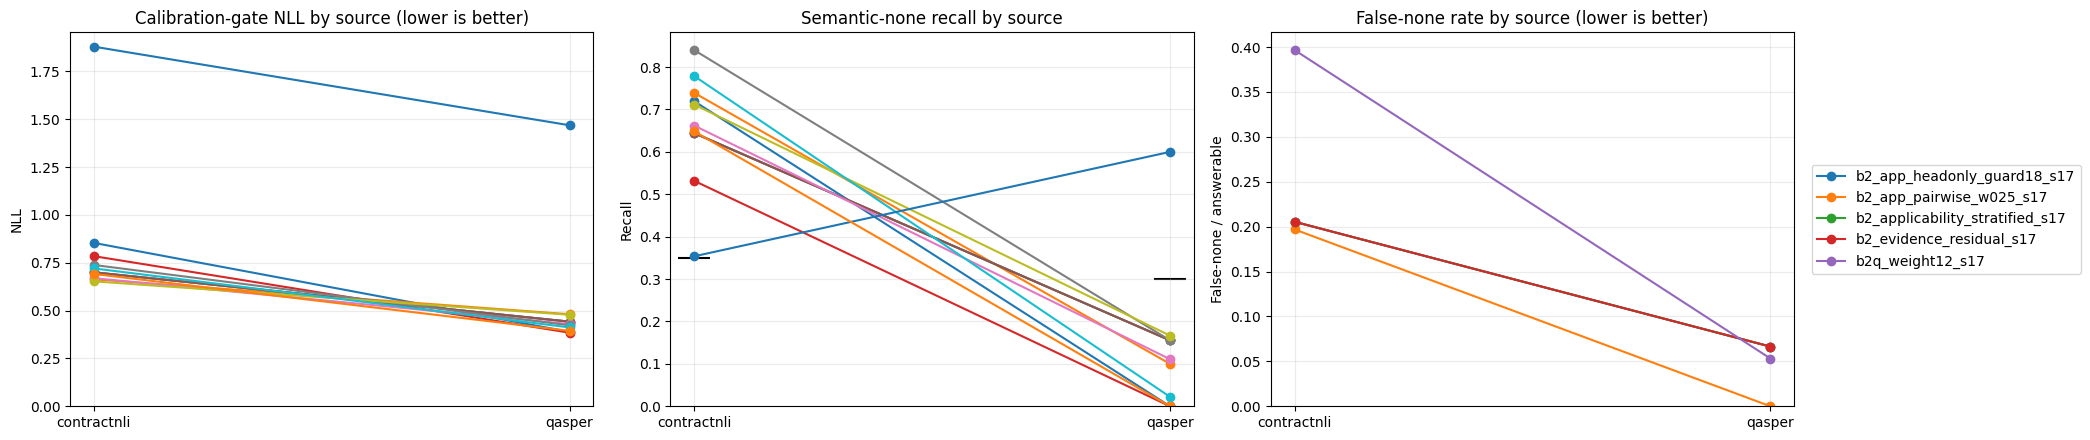

,epoch,source_macro_nll,source_macro_brier,qasper_none_recall,eligible
0,0,0.564568,0.339335,0.300885,False
1,1,0.598877,0.361720,0.309735,False
2,2,0.634597,0.386333,0.300885,False
3,3,0.622864,0.377930,0.309735,False
4,4,0.619287,0.375434,0.309735,False
5,5,0.620440,0.376255,0.309735,False
6,6,0.622760,0.377919,0.309735,False
7,7,0.623518,0.378476,0.309735,False
8,8,0.623085,0.378187,0.309735,False


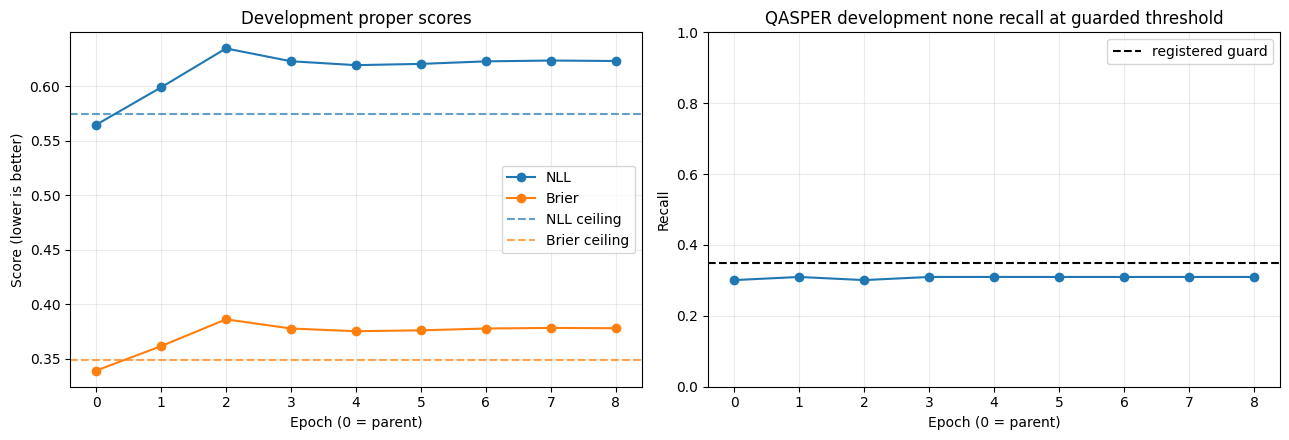

,model,source,threshold,semantic_none_recall,semantic_none_precision,false_none_rate,roc_auc,average_precision,gate_eligible
0,b2_app_headonly_guard18_s17,contractnli,0.543229,0.575099,0.718519,0.162625,0.784702,0.702872,True
1,b2_app_pairwise_w025_s17,contractnli,0.370430,0.577075,0.663636,0.211127,0.757159,0.692208,False
2,b2_evidence_residual_s17,contractnli,0.543229,0.575099,0.718519,0.162625,0.784702,0.702872,True
3,b2_app_headonly_guard18_s17,qasper,0.210894,0.311111,0.231405,0.154485,0.617257,0.184149,True
4,b2_app_pairwise_w025_s17,qasper,0.114193,0.333333,0.191083,0.210963,0.592451,0.175834,False
5,b2_evidence_residual_s17,qasper,0.210894,0.311111,0.231405,0.154485,0.617257,0.184149,True


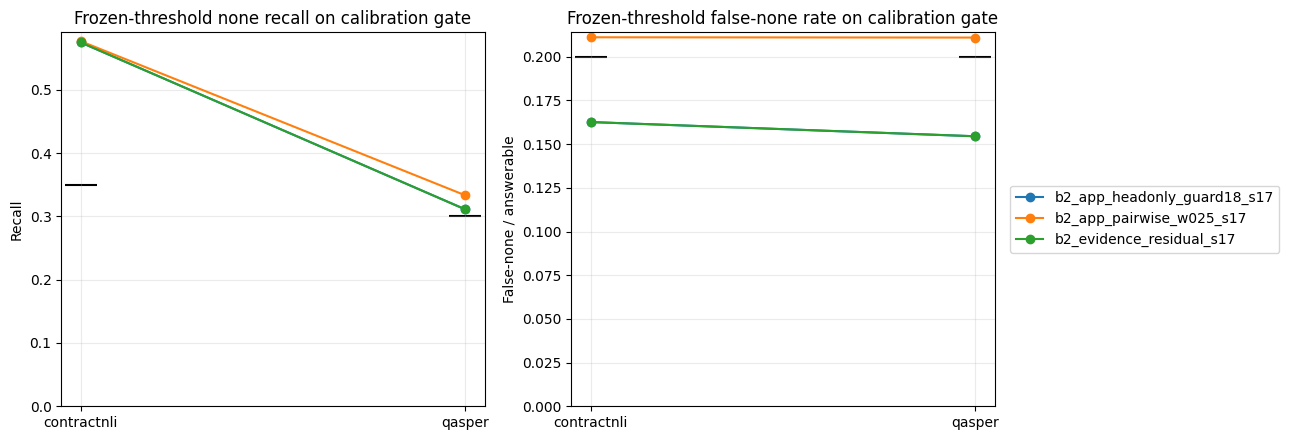

Saved strict-JSON Phase 4D comparison snapshot: /content/drive/MyDrive/Colab Notebooks/OpenKind_Phase4D_EvidenceAware_Applicability_results/20260921T013558Z/comparison_snapshot_20260922T200741Z.json


In [ ]:
import matplotlib.pyplot as plt

comparison_rows = []

def append_metric_rows(model_name, metrics_by_source, kind):
    for source_name, metrics in metrics_by_source.items():
        comparison_rows.append({
            "model": model_name,
            "kind": kind,
            "source": source_name,
            "n": metrics.get("n"),
            "accuracy": metrics.get("accuracy"),
            "balanced_accuracy": metrics.get("balanced_accuracy"),
            "macro_f1": metrics.get("macro_f1"),
            "nll": metrics.get("nll"),
            "brier": metrics.get("brier"),
            "ece15": metrics.get("ece15"),
            "semantic_none_n": metrics.get("semantic_none_n"),
            "semantic_none_true_positive": metrics.get(
                "semantic_none_true_positive"
            ),
            "semantic_none_false_positive": metrics.get(
                "semantic_none_false_positive"
            ),
            "predicted_none_n": metrics.get("predicted_none_n"),
            "semantic_none_recall": metrics.get("semantic_none_recall"),
            "semantic_none_precision": metrics.get("semantic_none_precision"),
            "answerable_n": metrics.get("answerable_n"),
            "answerable_accuracy": metrics.get("answerable_accuracy"),
            "answerable_non_none_recall": metrics.get(
                "answerable_non_none_recall"
            ),
            "false_none_rate": metrics.get("false_none_rate"),
            "applicability_balanced_accuracy": metrics.get(
                "applicability_balanced_accuracy"
            ),
        })

append_metric_rows(
    "historical_reference",
    BASE_NONFINAL["reference_by_source"],
    "baseline",
)
append_metric_rows(
    "phase4a1_b1_original",
    BASE_NONFINAL["custom_by_source"],
    "baseline",
)

variant_reports = []
for phase_kind, root in (
    ("phase4a2", PHASE4A2_COMPARISON_ROOT),
    ("phase4b2", PHASE4B2_COMPARISON_ROOT),
    ("phase4b3", PHASE4B3_COMPARISON_ROOT),
    ("phase4c", PHASE4C_COMPARISON_ROOT),
    ("phase4d", COMPARISON_ROOT),
):
    if not root.is_dir():
        continue
    for candidate in sorted(root.iterdir()):
        report_path = candidate / "NONFINAL_EVALUATION.json"
        contract_path = candidate / "EXPERIMENT_CONTRACT.json"
        if not report_path.is_file() or not contract_path.is_file():
            continue
        report = read_json(report_path)
        experiment = read_json(contract_path)
        if report.get("experiment_sha256") != experiment.get("experiment_sha256"):
            raise RuntimeError(f"Report/contract mismatch in {candidate}")
        if report.get("final_opened") is not False:
            raise RuntimeError(f"Final-opened report found in {candidate}")
        append_metric_rows(
            candidate.name,
            report["custom_by_source"],
            phase_kind,
        )
        variant_reports.append(report)

comparison = pd.DataFrame(comparison_rows)
display(
    comparison
    .sort_values(["source", "kind", "model"])
    .reset_index(drop=True)
)

macro_columns = [
    "accuracy", "balanced_accuracy", "macro_f1", "nll",
    "brier", "ece15", "semantic_none_recall",
    "semantic_none_precision", "answerable_accuracy",
    "answerable_non_none_recall", "false_none_rate",
    "applicability_balanced_accuracy",
]
macro = (
    comparison
    .groupby(["model", "kind"], as_index=False)[macro_columns]
    .mean(numeric_only=True)
    .sort_values(["kind", "nll", "model"])
)
display(macro)

if not comparison.empty:
    has_false_none = comparison["false_none_rate"].notna().any()
    panel_count = 3 if has_false_none else 2
    figure, axes = plt.subplots(
        1,
        panel_count,
        figsize=(7 * panel_count, 4.5),
    )
    axes = np.atleast_1d(axes)
    for model_name, group in comparison.groupby("model"):
        group = group.sort_values("source")
        axes[0].plot(
            group["source"],
            group["nll"],
            marker="o",
            label=model_name,
        )
        axes[1].plot(
            group["source"],
            group["semantic_none_recall"],
            marker="o",
            label=model_name,
        )
        if has_false_none and group["false_none_rate"].notna().any():
            diagnostic = group.dropna(subset=["false_none_rate"])
            axes[2].plot(
                diagnostic["source"],
                diagnostic["false_none_rate"],
                marker="o",
                label=model_name,
            )
    axes[0].set_title("Calibration-gate NLL by source (lower is better)")
    axes[0].set_ylabel("NLL")
    axes[1].set_title("Semantic-none recall by source")
    axes[1].set_ylabel("Recall")
    for source_name, floor in CFG["minimum_development_none_recall"].items():
        axes[1].scatter(
            [source_name],
            [floor],
            marker="_",
            s=500,
            color="black",
        )
    if has_false_none:
        axes[2].set_title("False-none rate by source (lower is better)")
        axes[2].set_ylabel("False-none / answerable")
    for axis in axes:
        axis.set_ylim(bottom=0)
        axis.grid(alpha=0.25)
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()



if TRAINING_REPORT is not None:
    trajectory_rows = []
    for record in TRAINING_REPORT["history"]:
        qasper_point = record["selection"]["applicability_operating_points"]["qasper"]
        trajectory_rows.append({
            "epoch": int(record["epoch"]),
            "source_macro_nll": record["selection"]["source_macro"]["nll"],
            "source_macro_brier": record["selection"]["source_macro"]["brier"],
            "qasper_none_recall": qasper_point["semantic_none_recall"],
            "eligible": record["selection"]["eligible"],
        })
    trajectory = pd.DataFrame(trajectory_rows).sort_values("epoch")
    display(trajectory)
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(trajectory["epoch"], trajectory["source_macro_nll"], marker="o", label="NLL")
    axes[0].plot(trajectory["epoch"], trajectory["source_macro_brier"], marker="o", label="Brier")
    axes[0].axhline(
        PARENT_DEVELOPMENT_SOURCE_MACRO["nll"] + CFG["proper_score_tolerance"],
        linestyle="--", color="tab:blue", alpha=0.7, label="NLL ceiling",
    )
    axes[0].axhline(
        PARENT_DEVELOPMENT_SOURCE_MACRO["brier"] + CFG["proper_score_tolerance"],
        linestyle="--", color="tab:orange", alpha=0.7, label="Brier ceiling",
    )
    axes[0].set_title("Development proper scores")
    axes[0].set_xlabel("Epoch (0 = parent)")
    axes[0].set_ylabel("Score (lower is better)")
    axes[0].legend()
    axes[1].plot(trajectory["epoch"], trajectory["qasper_none_recall"], marker="o")
    axes[1].axhline(
        CFG["development_selection_none_recall_guard"]["qasper"],
        linestyle="--", color="black", label="registered guard",
    )
    axes[1].set_title("QASPER development none recall at guarded threshold")
    axes[1].set_xlabel("Epoch (0 = parent)")
    axes[1].set_ylabel("Recall")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    for axis in axes:
        axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

operating_rows = []
for report in variant_reports:
    points = report.get("calibration_gate_applicability_operating_points")
    if not points:
        continue
    for source, metrics in points.items():
        operating_rows.append({
            "model": report["run_label"],
            "source": source,
            "threshold": metrics["threshold"],
            "semantic_none_recall": metrics["semantic_none_recall"],
            "semantic_none_precision": metrics["semantic_none_precision"],
            "false_none_rate": metrics["false_none_rate"],
            "roc_auc": metrics["roc_auc"],
            "average_precision": metrics["average_precision"],
            "gate_eligible": report.get(
                "calibration_gate_applicability_eligible", False
            ),
        })
operating = pd.DataFrame(operating_rows)
if not operating.empty:
    display(operating.sort_values(["source", "model"]).reset_index(drop=True))
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for model_name, group in operating.groupby("model"):
        group = group.sort_values("source")
        axes[0].plot(
            group["source"], group["semantic_none_recall"],
            marker="o", label=model_name,
        )
        axes[1].plot(
            group["source"], group["false_none_rate"],
            marker="o", label=model_name,
        )
    axes[0].set_title("Frozen-threshold none recall on calibration gate")
    axes[0].set_ylabel("Recall")
    axes[1].set_title("Frozen-threshold false-none rate on calibration gate")
    axes[1].set_ylabel("False-none / answerable")
    for source, floor in CFG["minimum_development_none_recall"].items():
        axes[0].scatter([source], [floor], marker="_", s=500, color="black")
    for source, ceiling in CFG["formal_gate_false_none_rate_cap"].items():
        axes[1].scatter([source], [ceiling], marker="_", s=500, color="black")
    for axis in axes:
        axis.set_ylim(bottom=0)
        axis.grid(alpha=0.25)
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()

if variant_reports:
    snapshot = {
        "schema": "openkind-phase4d-comparison-snapshot/v1",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "base_run_id": BASE_RUN_ID,
        "models": sorted(comparison["model"].unique()),
        "rows": comparison.to_dict("records"),
        "source_macro": macro.to_dict("records"),
        "applicability_operating_points": operating.to_dict("records"),
        "final_opened": False,
    }
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    snapshot_path = COMPARISON_ROOT / f"comparison_snapshot_{stamp}.json"
    if not snapshot_path.exists():
        atomic_json(snapshot, snapshot_path)
    print("Saved strict-JSON Phase 4D comparison snapshot:", snapshot_path)
else:
    print("No comparison report is available yet.")


## 11. Terminal non-final decision; final remains unavailable


In [ ]:
def open_final_split(*args, **kwargs):
    raise PermissionError(
        "Final evaluation is intentionally unavailable in Phase 4D. "
        "A separate confirmatory notebook requires a locked non-final pass and "
        "successful pre-registered replication."
    )

if store is not None and "final" in store.accessed_splits:
    raise AssertionError("Final split was accessed.")
if REPORT is not None and REPORT.get("final_opened") is not False:
    raise AssertionError("Non-final report has an invalid final status.")

if REPORT is not None:
    checks = {
        "development_selection": REPORT["selected_development"]["eligible"],
        "policy_development_applicability": REPORT[
            "policy_development_applicability_eligible"
        ],
        "calibration_gate_applicability": REPORT[
            "calibration_gate_applicability_eligible"
        ],
        "policy_development_cost": REPORT["policy_development_cost_eligible"],
        "calibration_gate_policy_cost": REPORT[
            "calibration_gate_policy_cost_eligible"
        ],
        "calibration_gate_proper_scores": REPORT[
            "calibration_gate_proper_score_nonregression"
        ]["eligible"],
    }
    if bool(all(checks.values())) != bool(REPORT["overall_nonfinal_pass"]):
        raise AssertionError("Terminal pass flag is inconsistent with component gates.")

    print("Selected epoch:", REPORT["selected_epoch"])
    print("Terminal non-final checks:", json.dumps(checks, indent=2, allow_nan=False))
    print(
        "Development guarded operating points:",
        REPORT["selected_development"]["applicability_operating_points"],
    )
    print(
        "Policy-development applicability operating points:",
        REPORT["applicability_thresholds_selected_on_policy_development"],
    )
    print(
        "Calibration-gate applicability operating points:",
        REPORT["calibration_gate_applicability_operating_points"],
    )
    print("Transferred automation policy:", REPORT["policy_applied_to_calibration_gate"])
    print(
        "Calibration proper-score gate:",
        REPORT["calibration_gate_proper_score_nonregression"],
    )

    if REPORT["overall_nonfinal_pass"]:
        print(
            "PHASE 4D PASSED EVERY PREDECLARED NON-FINAL GATE. Preserve this run "
            "unchanged and create a separate replication notebook for seeds 42 and 123. "
            "Final remains closed."
        )
    else:
        failed = [name for name, passed in checks.items() if not passed]
        print(
            "PHASE 4D FAILED THE PREDECLARED NON-FINAL CONTRACT. Failed checks: "
            f"{failed}. Do not sweep this residual, extend epochs, or run replication "
            "seeds. Preserve the result and move to reviewed supervision or representation "
            "learning. Final remains closed."
        )

print("Phase 4D is terminal for the frozen evidence-diagnostic residual hypothesis.")
